

# **Engineering Statistics and Probability**
## **Computer Assignment 5**
---

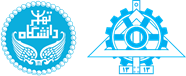

[**School of Electrical and Computer Engineering**, **College of Engineering**, **University of Tehran**](https://ece.ut.ac.ir/)

**Instructors:** Dr. Bahrak, Dr. Vahhabi

**Designers:** [Artin Tavassoli](mailto:artin.tavassoli2@gmail.com), [Mohammad Erfan Danaee](mailto:medanaee@gmail.com)

## **Topic:** Sum of Random Variables, Conditional Distribution, Covariance, and Functions of Two Random Variables

### **Submission Date:**

---

### ℹ️ Student information
+ First name: Amin
+ Last Name: Gholami
+ SID: 810103480

---

### We will use the following R packages:

*   [`dplyr`](https://cran.r-project.org/web/packages/dplyr/vignettes/dplyr.html): A popular and easy-to-use package for data manipulation in R. (for Qestion 2)
*   [`ggplot2`](https://ggplot2.tidyverse.org/): A powerful package for creating visualizations in R.
*   [`magrittr`](https://magrittr.tidyverse.org) : An package that introduces the pipe operator (%>%) to make code more readable by chaining

+ ⚠️ **Remove comment lines on first run.**


In [ ]:
install.packages("magrittr")
install.packages("dplyr")
install.packages("ggplot2")
library(magrittr)
library(dplyr)
library(ggplot2)
set.seed(42)
options(repr.plot.width = 15, repr.plot.height = 6)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Question 1 (25 points🎯)
## Sum of RVs and function of two RVs ⭐

A company wants to obtain a distribution of the loss it will incur at the end of the upcoming week.

Suppose a company is losing money due to product returns. The number of products of type `a` and `b` returned to the company each day is exponentially distributed and independent of each other, and the company loses 1\$ for each product returned.
Let $X_i$ number of products of type `a` and $Y_i$ number of products of type `b` be returned on day i.

 $$X_i , Y_i \sim Exp(λ = 0.01)$$

### 0. Complete the following two functions to plot the histogram and PDF of the data. (5 points🎯)

+ Note: You can use `geom_density` to plot the PDF.

In [ ]:
plot_hist <- function(data, bins = 30, fill_color = "skyblue", line_color = "white") {
  data_df <- data.frame(value = data)
  ggplot(data_df, aes(x = value)) +
    geom_histogram(bins = bins, fill = fill_color, color = line_color, alpha = 0.7) +
    theme_minimal() +
    labs(title = "Histogram of Data", x = "Value", y = "Frequency")
}

plot_pdf <- function(data, line_color = "blue", fill_color = "lightblue", alpha = 0.5) {
  data_df <- data.frame(value = data)
  ggplot(data_df, aes(x = value)) +
    geom_density(fill = fill_color, alpha = alpha, color = line_color) +
    theme_minimal() +
    labs(title = "PDF of Data", x = "Value", y = "Density")
}

### 1. Write down the company's loss due to the return of product A after one week. Let's assume this value is equal to $D$. (1 points🎯)

### 2. By generating 100,000 samples of the loss each day caused by product a, obtain 100,000 samples of the $D$. Then plot its PDF and histogram. (2 points🎯)



🔴 **TO DO**

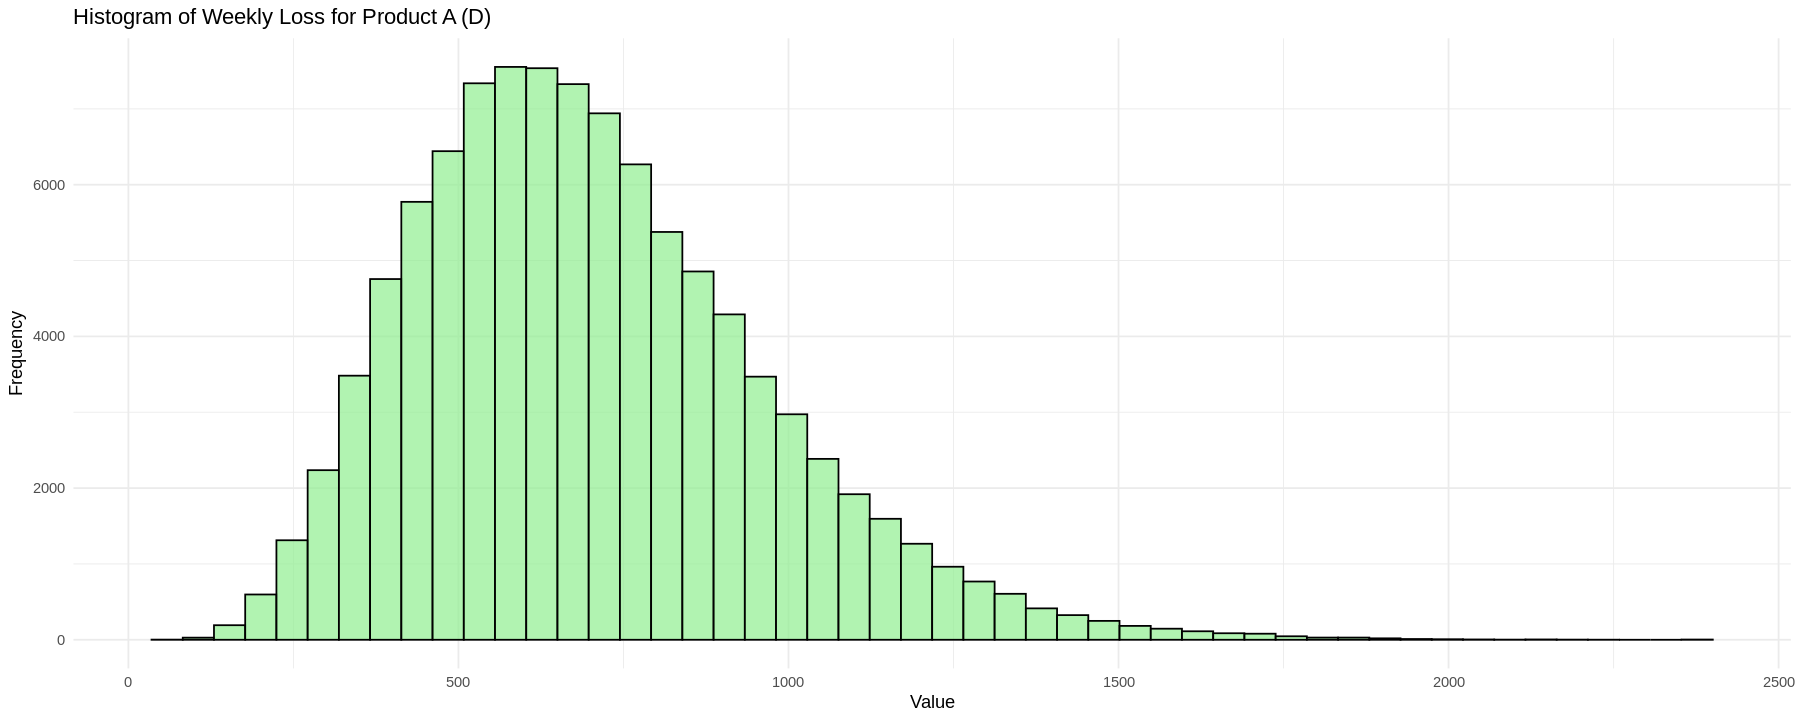

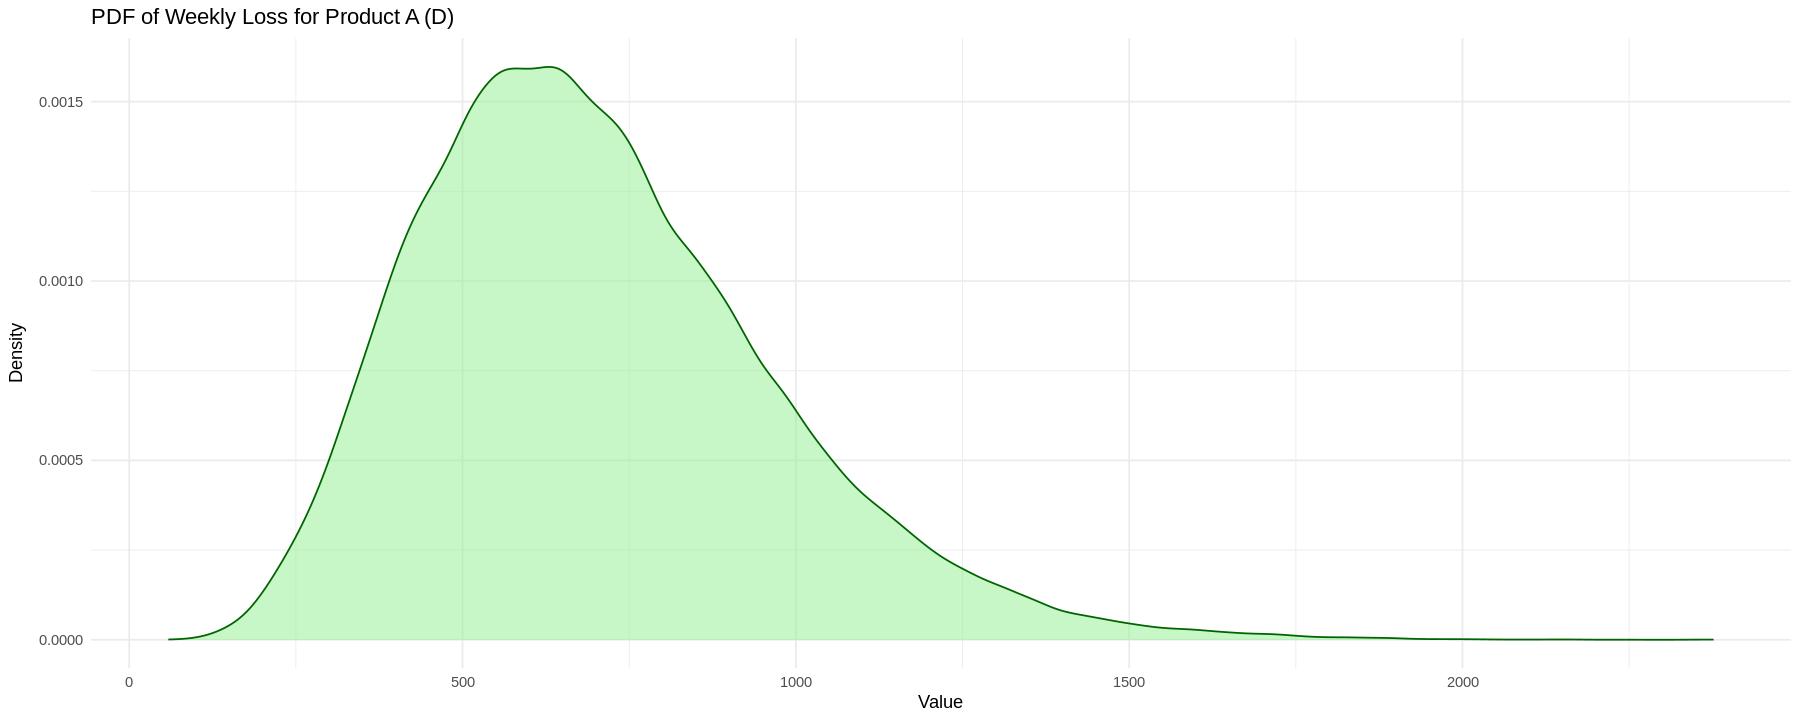

In [ ]:
lambda_val <- 0.01
num_samples <- 100000
num_days_in_week <- 7

# Generate daily losses for product A for 100,000 weeks (7 days * 100,000 samples)
daily_losses_a <- rexp(num_days_in_week * num_samples, rate = lambda_val)

# Reshape into a matrix (7 rows for days, 100,000 columns for weeks)
daily_losses_matrix <- matrix(daily_losses_a, nrow = num_days_in_week, ncol = num_samples)

# Sum up the daily losses for each week to get D_samples
D_samples <- colSums(daily_losses_matrix)

# Plot histogram of D_samples
print(plot_hist(D_samples, bins = 50, fill_color = "lightgreen", line_color = "black") +
        labs(title = "Histogram of Weekly Loss for Product A (D)"))

# Plot PDF of D_samples
print(plot_pdf(D_samples, line_color = "darkgreen", fill_color = "lightgreen") +
        labs(title = "PDF of Weekly Loss for Product A (D)"))

### 3. Calculate the mean and variance of the resulting distribution. (1 points🎯)

In [ ]:
mean_D <- mean(D_samples)
print(paste("Mean of D_samples:", mean_D))

var_D <- var(D_samples)
print(paste("Variance of D_samples:", var_D))

[1] "Mean of D_samples: 699.872066346266"
[1] "Variance of D_samples: 69742.4510643489"


The total loss of the company after `n` days is the sum of `n` identical and independent exponential variables.
This sum has a distribution called the [**gamma distribution**](https://en.wikipedia.org/wiki/Gamma_distribution)

### 4. By studying this distribution, obtain the gamma distribution parameters for D and plot it's PDF. (2 points🎯)

🔴 **TO DO**

In [ ]:
  plot_pdf_theory <- function(x, y,
                    line_color = "blue",
                    line_size = 1,
                    title = "Plot",
                    xlab = "x",
                    ylab = "y") {
  ggplot(data.frame(x, y), aes(x, y)) +
    geom_line(color = line_color, linewidth = line_size) + # Changed size to linewidth
    theme_minimal() +
    labs(title = title, x = xlab, y = ylab)
}

[1] "Theoretical Gamma Distribution Parameters for D:"
[1] "  Shape (k): 7"
[1] "  Rate (lambda): 0.01"
[1] "  Scale (theta): 100"



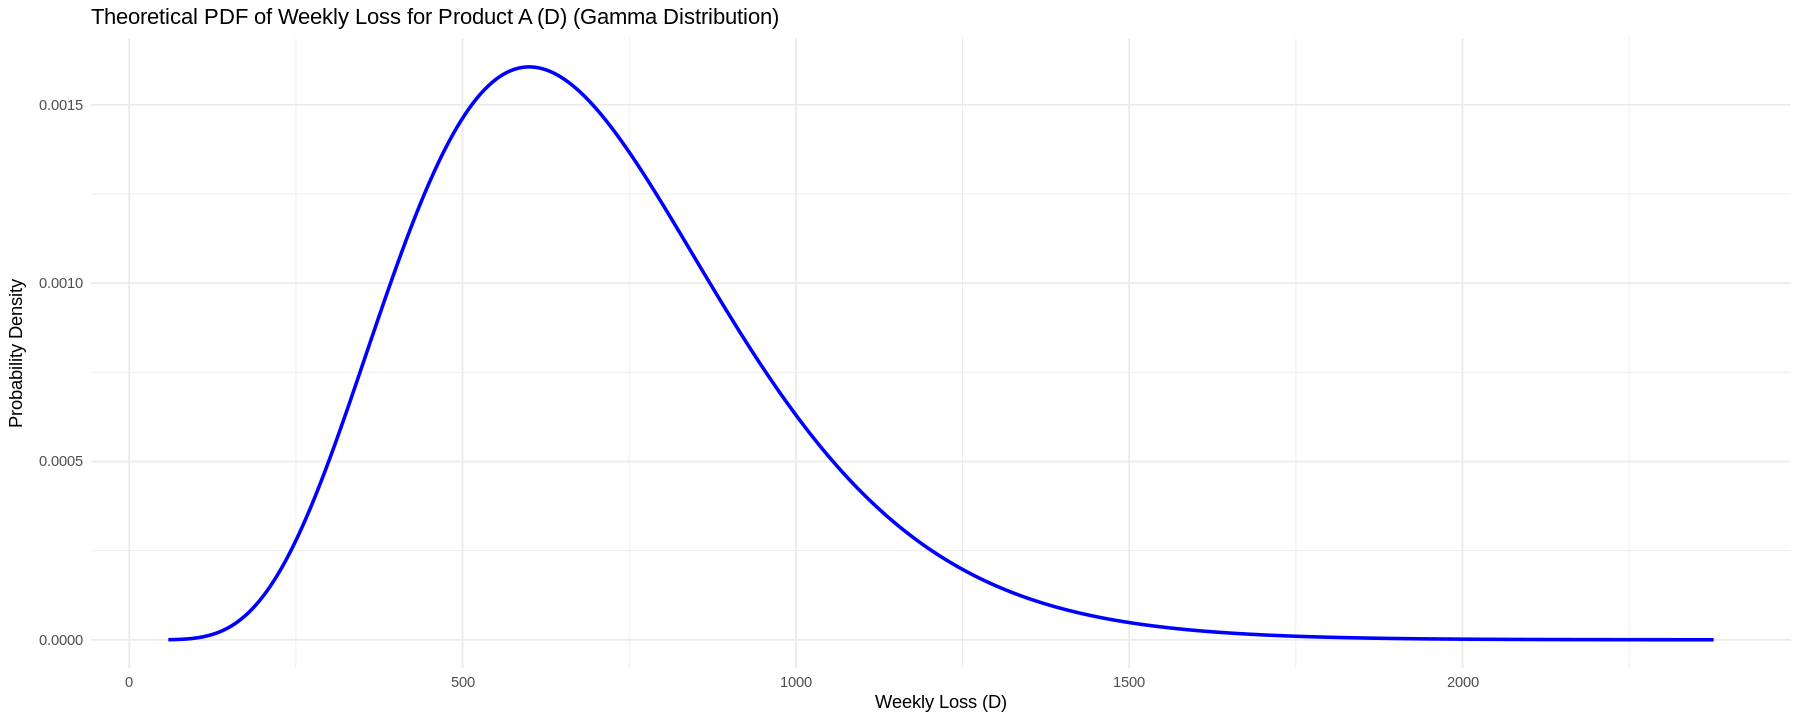

In [ ]:
# For a sum of n i.i.d. Exponential(lambda) random variables, the distribution is Gamma(shape = n, rate = lambda).
# In our case, n = num_days_in_week = 7 and lambda = lambda_val = 0.01.
shape_D_theory <- num_days_in_week
rate_D_theory <- lambda_val

scale_D_theory <- 1 / rate_D_theory

print(paste("Theoretical Gamma Distribution Parameters for D:"))
print(paste("  Shape (k):", shape_D_theory))
print(paste("  Rate (lambda):", rate_D_theory))
print(paste("  Scale (theta):", scale_D_theory))
cat('\n')

x_values_D <- seq(min(D_samples), max(D_samples), length.out = 1000)
y_values_D <- dgamma(x_values_D, shape = shape_D_theory, rate = rate_D_theory)

print(plot_pdf_theory(x_values_D, y_values_D,
                      title = "Theoretical PDF of Weekly Loss for Product A (D) (Gamma Distribution)",
                      xlab = "Weekly Loss (D)",
                      ylab = "Probability Density"))

### 5. Calculate the mean and variance theoretically and compare with section 3. (1 points🎯)

🔴 **TO DO**

In [ ]:
# Theoretical mean and variance for a Gamma distribution with shape k and rate lambda
# Mean = k / lambda
# Variance = k / (lambda^2)

theoretical_mean_D <- shape_D_theory / rate_D_theory
theoretical_var_D <- shape_D_theory / (rate_D_theory^2)

print(paste("Theoretical Mean of D:", theoretical_mean_D))
print(paste("Theoretical Variance of D:", theoretical_var_D))

print(paste("Empirical Mean of D (from Section 3):", mean_D))
print(paste("Empirical Variance of D (from Section 3):", var_D))

print("Comparison:")
print(paste("Difference in Mean (Theoretical - Empirical):", theoretical_mean_D - mean_D))
print(paste("Difference in Variance (Theoretical - Empirical):", theoretical_var_D - var_D))

[1] "Theoretical Mean of D: 700"
[1] "Theoretical Variance of D: 70000"
[1] "Empirical Mean of D (from Section 3): 699.872066346266"
[1] "Empirical Variance of D (from Section 3): 69742.4510643489"
[1] "Comparison:"
[1] "Difference in Mean (Theoretical - Empirical): 0.127933653734431"
[1] "Difference in Variance (Theoretical - Empirical): 257.54893565111"


Now suppose the company wants to know what percentage of the company's loss after 7 days is related to product a.

### 6. Write down this ratio. plot 100,000 samples of this ratio by generating random samples of the company's losses. Also calculate the mean and variance of the data. (2 points🎯)

This new distribution is called the [**beta distribution**](https://en.wikipedia.org/wiki/Beta_distribution).

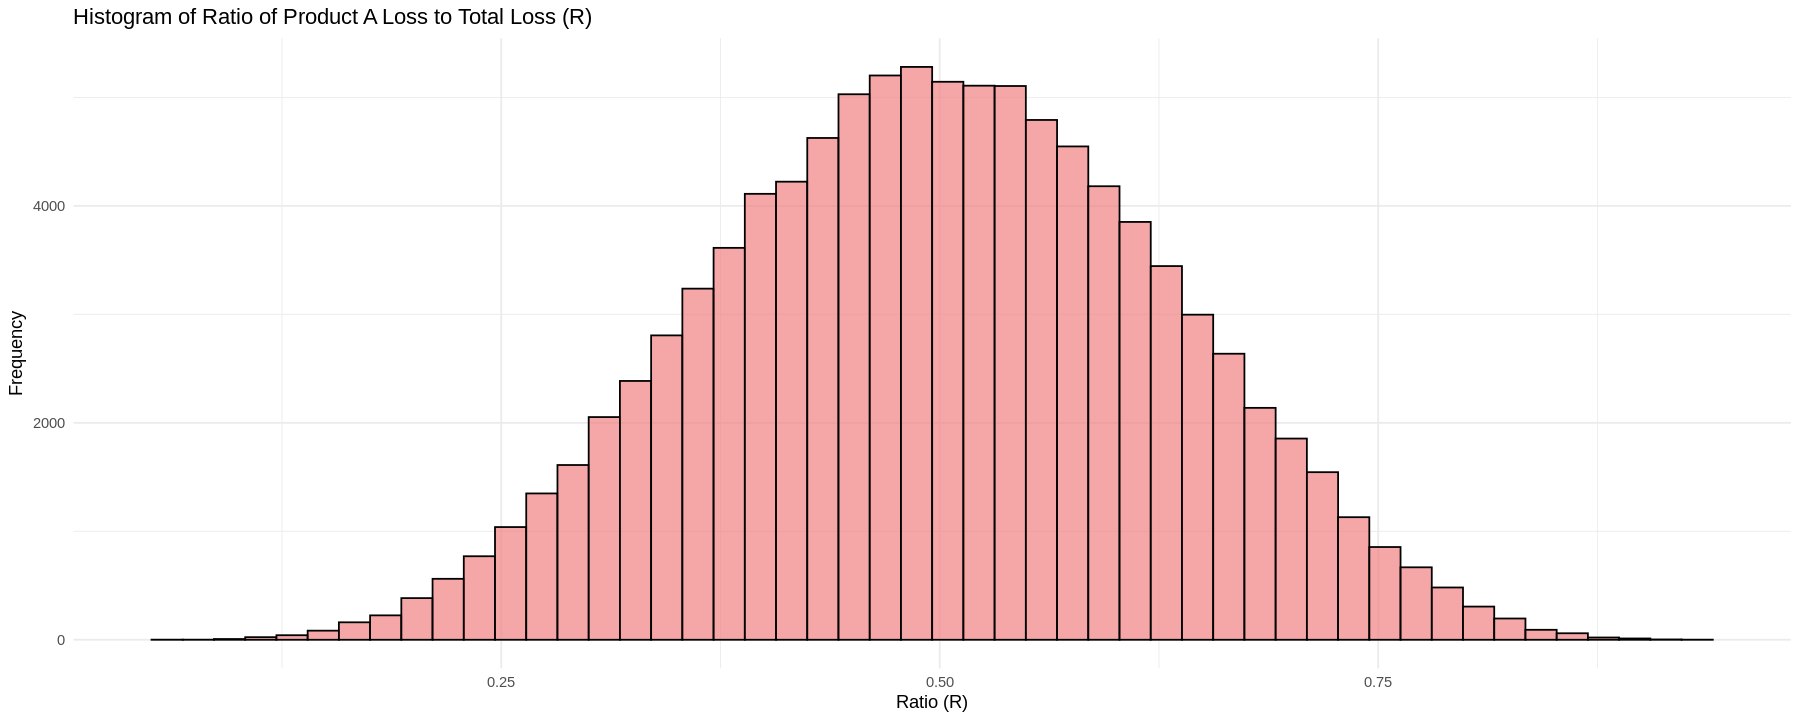


[1] "Mean of Ratio (R): 0.499999967168393"
[1] "Variance of Ratio (R): 0.016648162779955"



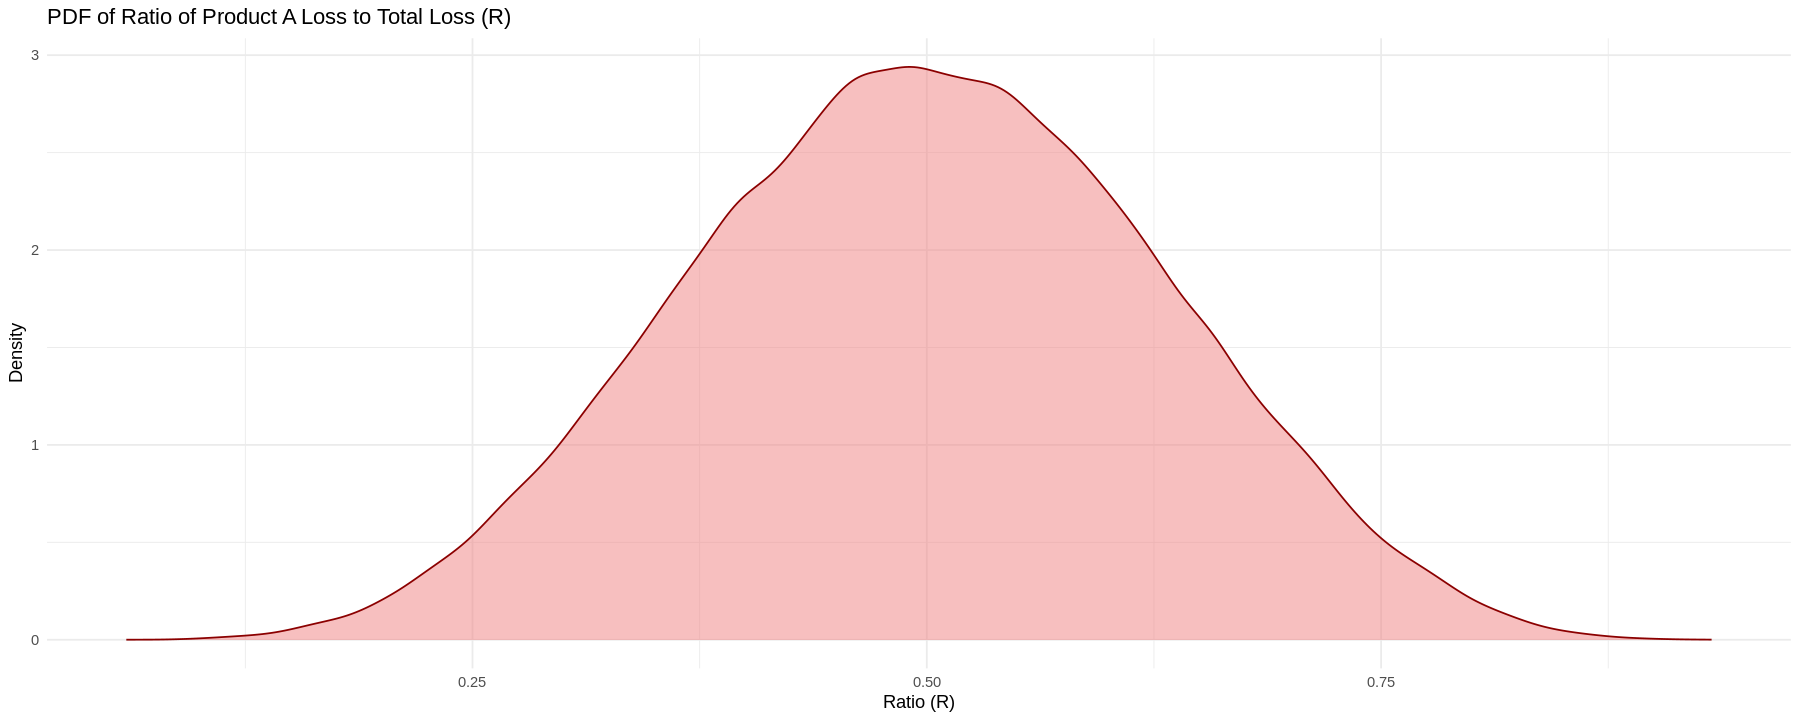

In [ ]:
# Let D_A be the loss from product A and D_B be the loss from product B.
# Both D_A and D_B are sums of 7 i.i.d. Exponential(lambda=0.01) random variables.
# So, D_A ~ Gamma(shape=7, rate=0.01) and D_B ~ Gamma(shape=7, rate=0.01).
# The total loss is D_total = D_A + D_B.

daily_losses_b <- rexp(num_days_in_week * num_samples, rate = lambda_val)
daily_losses_matrix_b <- matrix(daily_losses_b, nrow = num_days_in_week, ncol = num_samples)
D_B_samples <- colSums(daily_losses_matrix_b)

# Calculate the ratio R = D_A / (D_A + D_B)
ratio_samples <- D_samples / (D_samples + D_B_samples)

print(plot_hist(ratio_samples, bins = 50, fill_color = "lightcoral", line_color = "black") +
        labs(title = "Histogram of Ratio of Product A Loss to Total Loss (R)",
             x = "Ratio (R)", y = "Frequency"))

print(plot_pdf(ratio_samples, line_color = "darkred", fill_color = "lightcoral") +
        labs(title = "PDF of Ratio of Product A Loss to Total Loss (R)",
             x = "Ratio (R)", y = "Density"))

mean_ratio <- mean(ratio_samples)
var_ratio <- var(ratio_samples)

cat('\n')
print(paste("Mean of Ratio (R):", mean_ratio))
print(paste("Variance of Ratio (R):", var_ratio))
cat('\n')

### 7. By studying this distribution, calculate its parameters, then theoretically estimate its mean and variance and compare it with Section 6. (5 points🎯)

🔴 **TO DO**

In [ ]:
# We have two independent Gamma random variables: D_A ~ Gamma(shape = k_A, rate = lambda_A) and D_B ~ Gamma(shape = k_B, rate = lambda_B).
# In our case, k_A = k_B = num_days_in_week = 7, and lambda_A = lambda_B = lambda_val = 0.01.

# When two independent Gamma random variables with parameters (k_A, lambda) and (k_B, lambda) are considered,
# the ratio R = D_A / (D_A + D_B) follows a Beta distribution with parameters (alpha = k_A, beta = k_B).

# So, for our case, the theoretical Beta distribution parameters are:
alpha_beta_theory <- shape_D_theory # which is num_days_in_week = 7
beta_beta_theory <- shape_D_theory  # which is num_days_in_week = 7

print(paste("Theoretical Beta Distribution Parameters for R:"))
print(paste("  Alpha (a):", alpha_beta_theory))
print(paste("  Beta (b):", beta_beta_theory))
cat('\n')

# Theoretical mean and variance for a Beta distribution with parameters alpha and beta:
# Mean = alpha / (alpha + beta)
# Variance = (alpha * beta) / ((alpha + beta)^2 * (alpha + beta + 1))
theoretical_mean_ratio <- alpha_beta_theory / (alpha_beta_theory + beta_beta_theory)
theoretical_var_ratio <- (alpha_beta_theory * beta_beta_theory) / ((alpha_beta_theory + beta_beta_theory)^2 * (alpha_beta_theory + beta_beta_theory + 1))

print(paste("Theoretical Mean of Ratio (R):", theoretical_mean_ratio))
print(paste("Theoretical Variance of Ratio (R):", theoretical_var_ratio))
cat('\n')

print(paste("Empirical Mean of Ratio (R) (from Section 6):", mean_ratio))
print(paste("Empirical Variance of Ratio (R) (from Section 6):", var_ratio))
cat('\n')

print("Comparison:")
print(paste("Difference in Mean (Theoretical - Empirical):", theoretical_mean_ratio - mean_ratio))
print(paste("Difference in Variance (Theoretical - Empirical):", theoretical_var_ratio - var_ratio))

[1] "Theoretical Beta Distribution Parameters for R:"
[1] "  Alpha (a): 7"
[1] "  Beta (b): 7"

[1] "Theoretical Mean of Ratio (R): 0.5"
[1] "Theoretical Variance of Ratio (R): 0.0166666666666667"

[1] "Empirical Mean of Ratio (R) (from Section 6): 0.499999967168393"
[1] "Empirical Variance of Ratio (R) (from Section 6): 0.016648162779955"

[1] "Comparison:"
[1] "Difference in Mean (Theoretical - Empirical): 3.28316068221035e-08"
[1] "Difference in Variance (Theoretical - Empirical): 1.85038867117106e-05"


### 8. Plot the PDF graph of the resulting beta distribution and compare it with the histogram in Section 6. (2 points🎯)

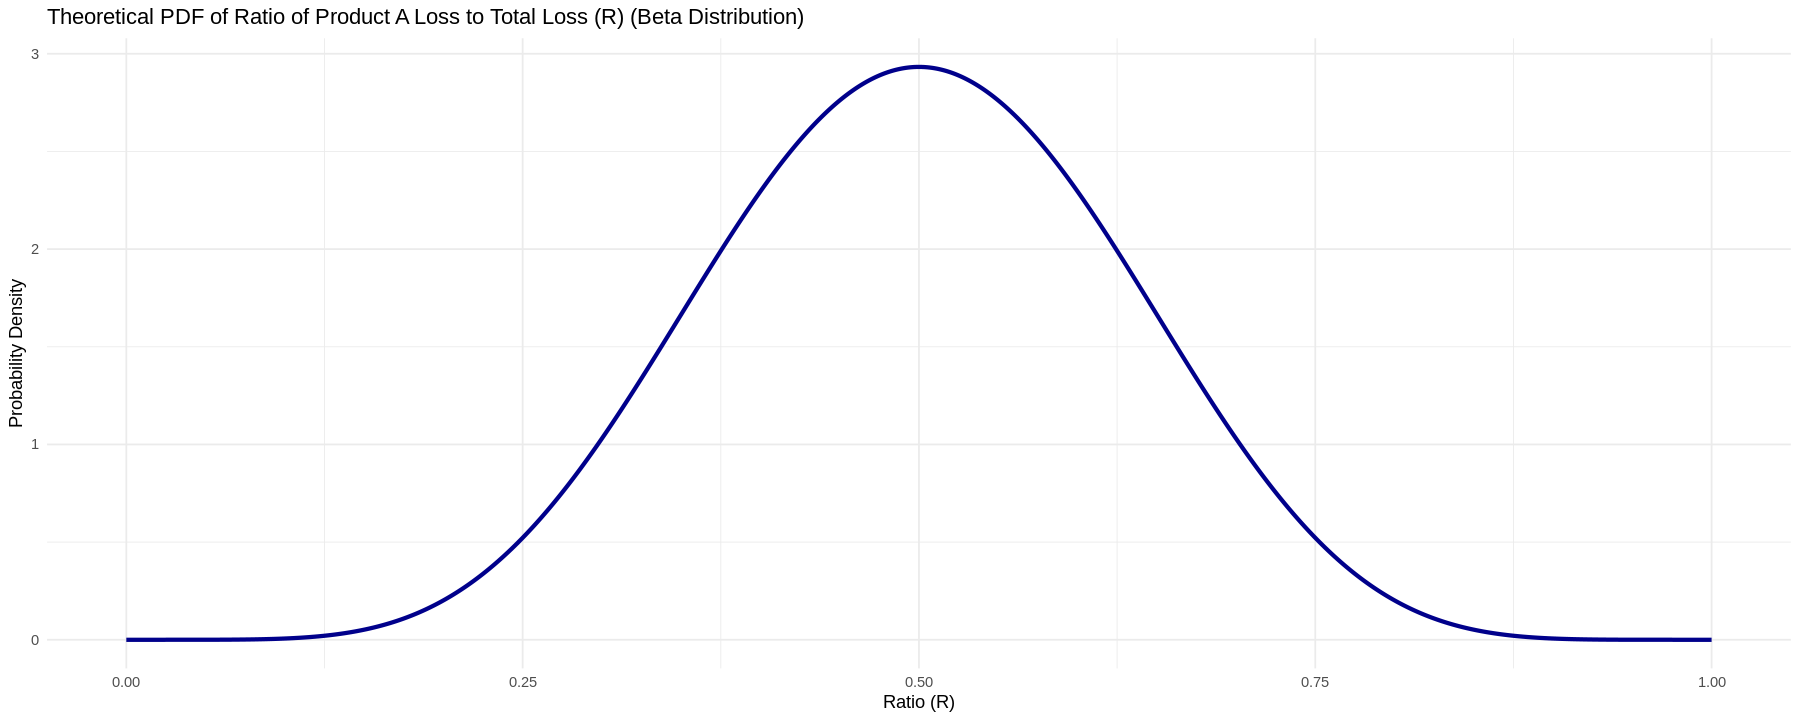

In [ ]:
x_values_beta <- seq(0, 1, length.out = 1000)

# Calculate y values (density) using the dbeta function with theoretical alpha and beta
y_values_beta <- dbeta(x_values_beta, shape1 = alpha_beta_theory, shape2 = beta_beta_theory)

print(plot_pdf_theory(x_values_beta, y_values_beta,
                      title = "Theoretical PDF of Ratio of Product A Loss to Total Loss (R) (Beta Distribution)",
                      xlab = "Ratio (R)",
                      ylab = "Probability Density",
                      line_color = "darkblue",
                      line_size = 1.2))

### 9. Now suppose the company wants to calculate the same ratio for a day instead of a week. Re-simulate this ratio. (2 points🎯)
### 10. What distribution does the resulting distribution resemble? Verify this with theoretical calculations. (2 points🎯)

🔴 **TO DO**

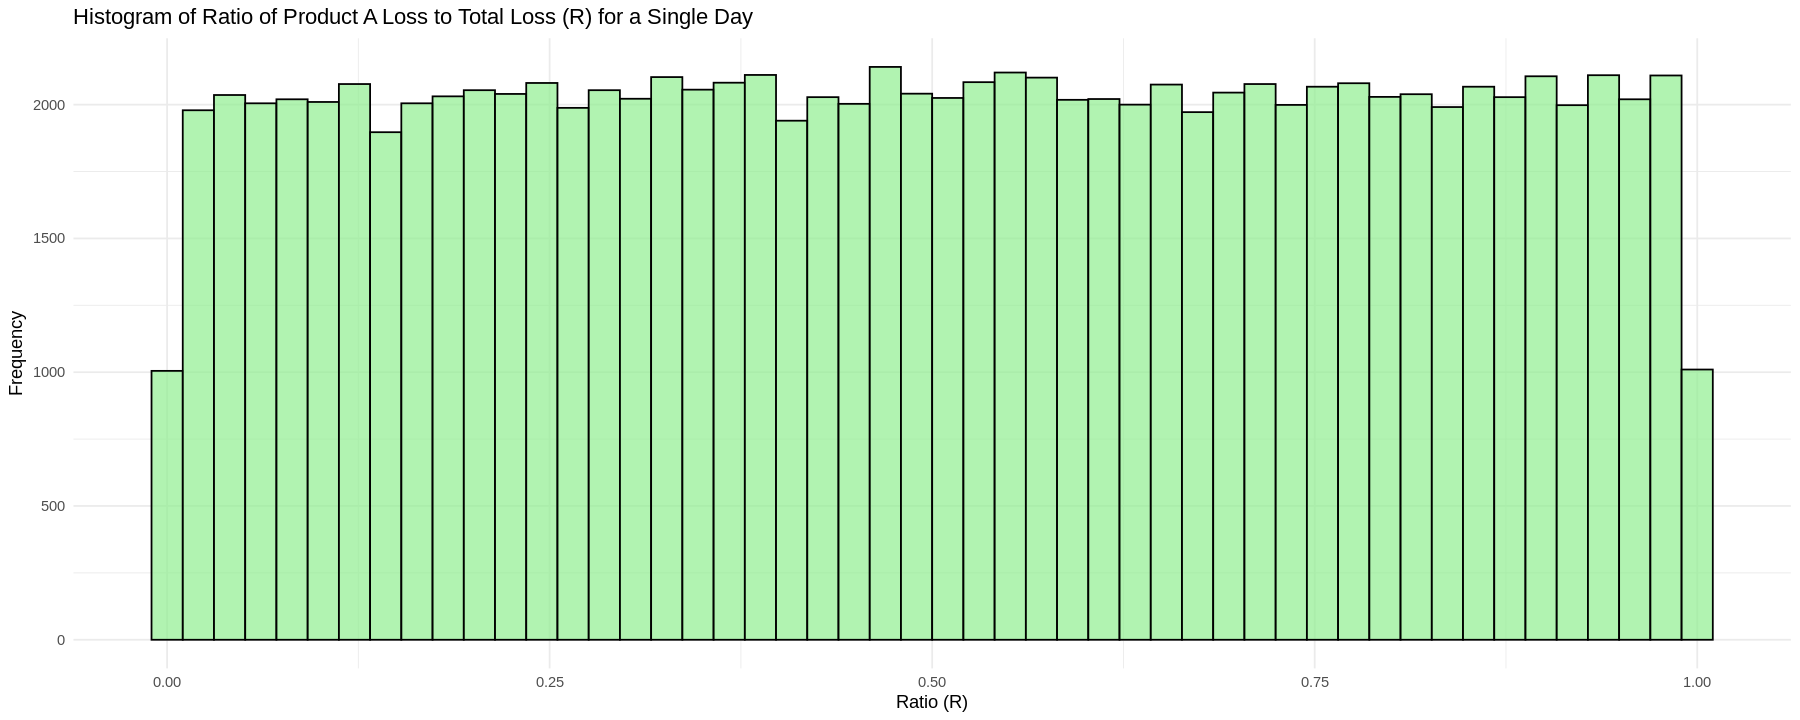


[1] "Mean of Single Day Ratio (R): 0.50158970023221"
[1] "Variance of Single Day Ratio (R): 0.0830579226896765"



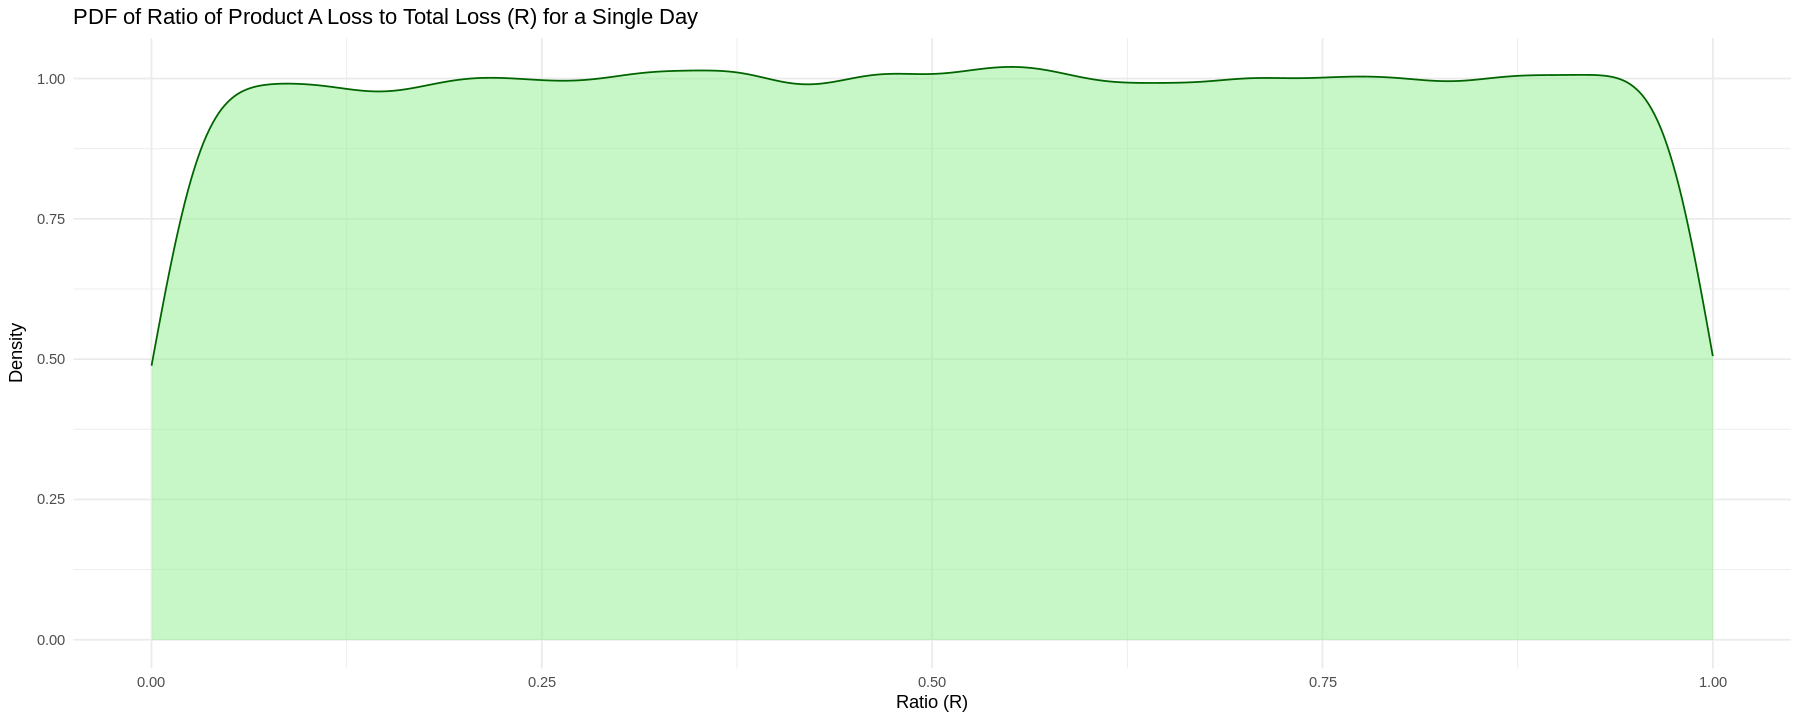

In [ ]:
# For a single day, n = 1.
num_days_for_day_ratio <- 1

# Generate daily losses for product A for 100,000 samples (for a single day)
daily_losses_a_single_day <- rexp(num_days_for_day_ratio * num_samples, rate = lambda_val)

# Generate daily losses for product B for 100,000 samples (for a single day)
daily_losses_b_single_day <- rexp(num_days_for_day_ratio * num_samples, rate = lambda_val)

# Calculate the ratio R_day = X_a / (X_a + X_b) for a single day
ratio_samples_single_day <- daily_losses_a_single_day / (daily_losses_a_single_day + daily_losses_b_single_day)

print(plot_hist(ratio_samples_single_day, bins = 50, fill_color = "lightgreen", line_color = "black") +
        labs(title = "Histogram of Ratio of Product A Loss to Total Loss (R) for a Single Day",
             x = "Ratio (R)", y = "Frequency"))

print(plot_pdf(ratio_samples_single_day, line_color = "darkgreen", fill_color = "lightgreen") +
        labs(title = "PDF of Ratio of Product A Loss to Total Loss (R) for a Single Day",
             x = "Ratio (R)", y = "Density"))

mean_ratio_single_day <- mean(ratio_samples_single_day)
var_ratio_single_day <- var(ratio_samples_single_day)

cat('\n')
print(paste("Mean of Single Day Ratio (R):", mean_ratio_single_day))
print(paste("Variance of Single Day Ratio (R):", var_ratio_single_day))
cat('\n')


[1] "Theoretical Beta Distribution Parameters for R (Single Day): 1 , 1"

[1] "Theoretical Mean of Single Day Ratio (R): 0.5"
[1] "Theoretical Variance of Single Day Ratio (R): 0.0833333333333333"

[1] "Comparison (Single Day Ratio):"
[1] "Difference in Mean (Theoretical - Empirical): -0.00158970023221006"
[1] "Difference in Variance (Theoretical - Empirical): 0.000275410643656784"



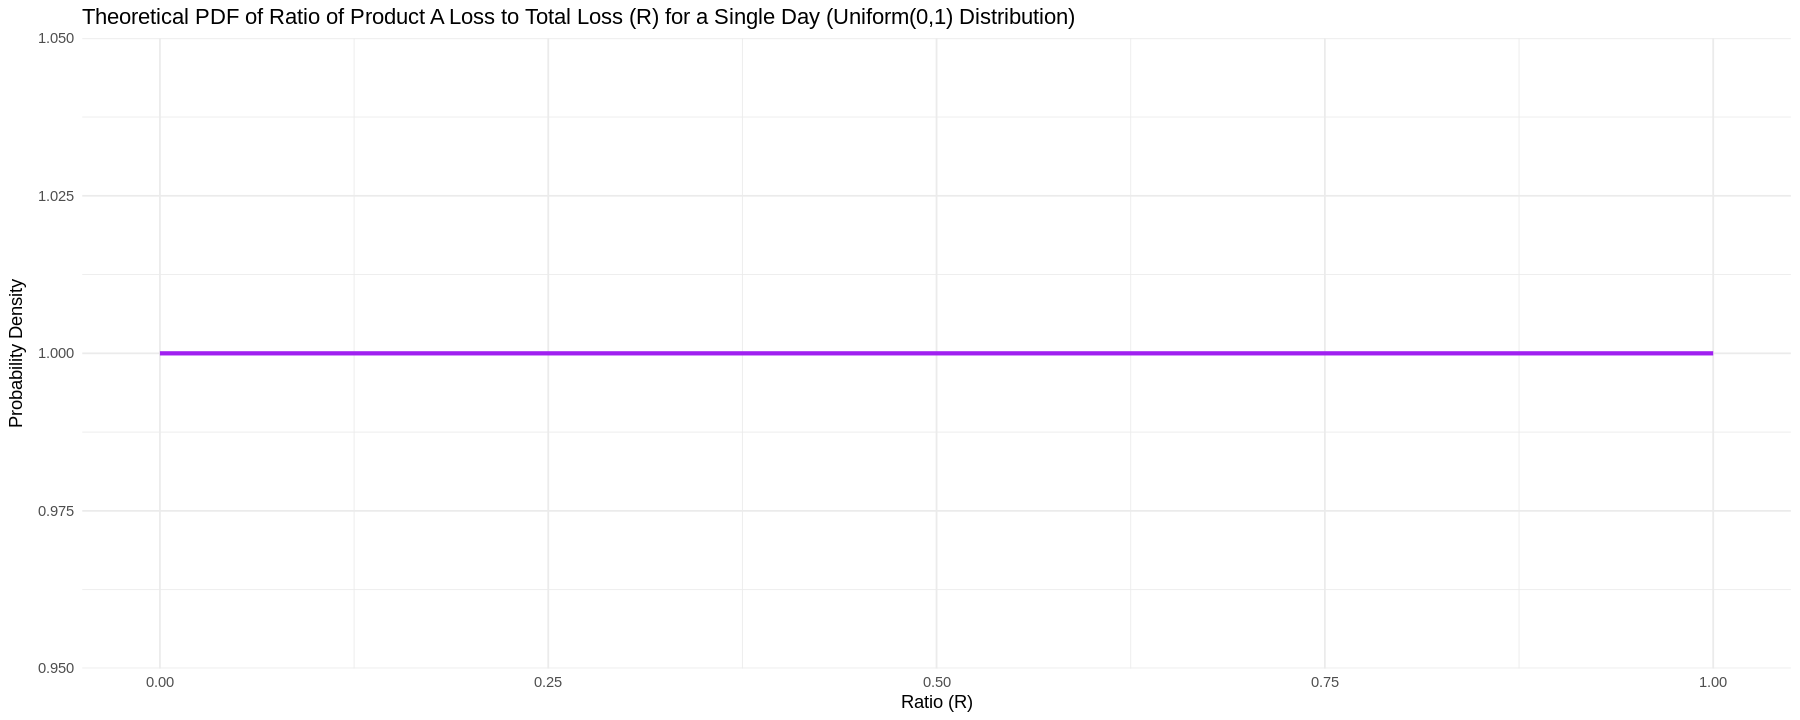

In [ ]:
# For a single day, D_A ~ Exp(lambda) and D_B ~ Exp(lambda).
# The ratio R = D_A / (D_A + D_B) where D_A and D_B are i.i.d. Exponential(lambda) random variables.
# This is a special case of the Beta distribution where shape1 = 1 and shape2 = 1. This is the Uniform(0,1) distribution.

alpha_beta_theory_single_day <- num_days_for_day_ratio # which is 1
beta_beta_theory_single_day <- num_days_for_day_ratio # which is 1

print(paste("Theoretical Beta Distribution Parameters for R (Single Day):", alpha_beta_theory_single_day, ",", beta_beta_theory_single_day))
cat('\n')

# Theoretical mean and variance for a Beta distribution with parameters alpha=1 and beta=1 (Uniform(0,1)):
# Mean = 1 / (1 + 1) = 0.5
# Variance = (1 * 1) / ((1 + 1)^2 * (1 + 1 + 1)) = 1 / (4 * 3) = 1/12

theoretical_mean_ratio_single_day <- alpha_beta_theory_single_day / (alpha_beta_theory_single_day + beta_beta_theory_single_day)
theoretical_var_ratio_single_day <- (alpha_beta_theory_single_day * beta_beta_theory_single_day) / ((alpha_beta_theory_single_day + beta_beta_theory_single_day)^2 * (alpha_beta_theory_single_day + beta_beta_theory_single_day + 1))

print(paste("Theoretical Mean of Single Day Ratio (R):", theoretical_mean_ratio_single_day))
print(paste("Theoretical Variance of Single Day Ratio (R):", theoretical_var_ratio_single_day))
cat('\n')

print("Comparison (Single Day Ratio):")
print(paste("Difference in Mean (Theoretical - Empirical):", theoretical_mean_ratio_single_day - mean_ratio_single_day))
print(paste("Difference in Variance (Theoretical - Empirical):", theoretical_var_ratio_single_day - var_ratio_single_day))
cat('\n')

x_values_uniform <- seq(0, 1, length.out = 1000)
y_values_uniform <- dunif(x_values_uniform, min = 0, max = 1)

print(plot_pdf_theory(x_values_uniform, y_values_uniform,
                      title = "Theoretical PDF of Ratio of Product A Loss to Total Loss (R) for a Single Day (Uniform(0,1) Distribution)",
                      xlab = "Ratio (R)",
                      ylab = "Probability Density",
                      line_color = "purple",
                      line_size = 1.2))

# Question 2 (25 points🎯)
## Covariance 🌡️

We will use the built-in **airquality** dataset in R, which contains weather data for New York in 1970.

We will focus on the **Day**, **Month**, and **Temp** columns. To represent the progression of the year, we will define a new variable called **Day Number**, which indicates the number of days passed since the beginning of the year.


## Familiarize With Dataset 🌦️ (7.5 points🎯)

### 1. Plot the temperature (**Temp**) against the **Day Number**. This will help you become familiar with the dataset and observe the general trend of temperature throughout the year.

In [ ]:
head(airquality)


,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


`geom_smooth()` using formula = 'y ~ x'


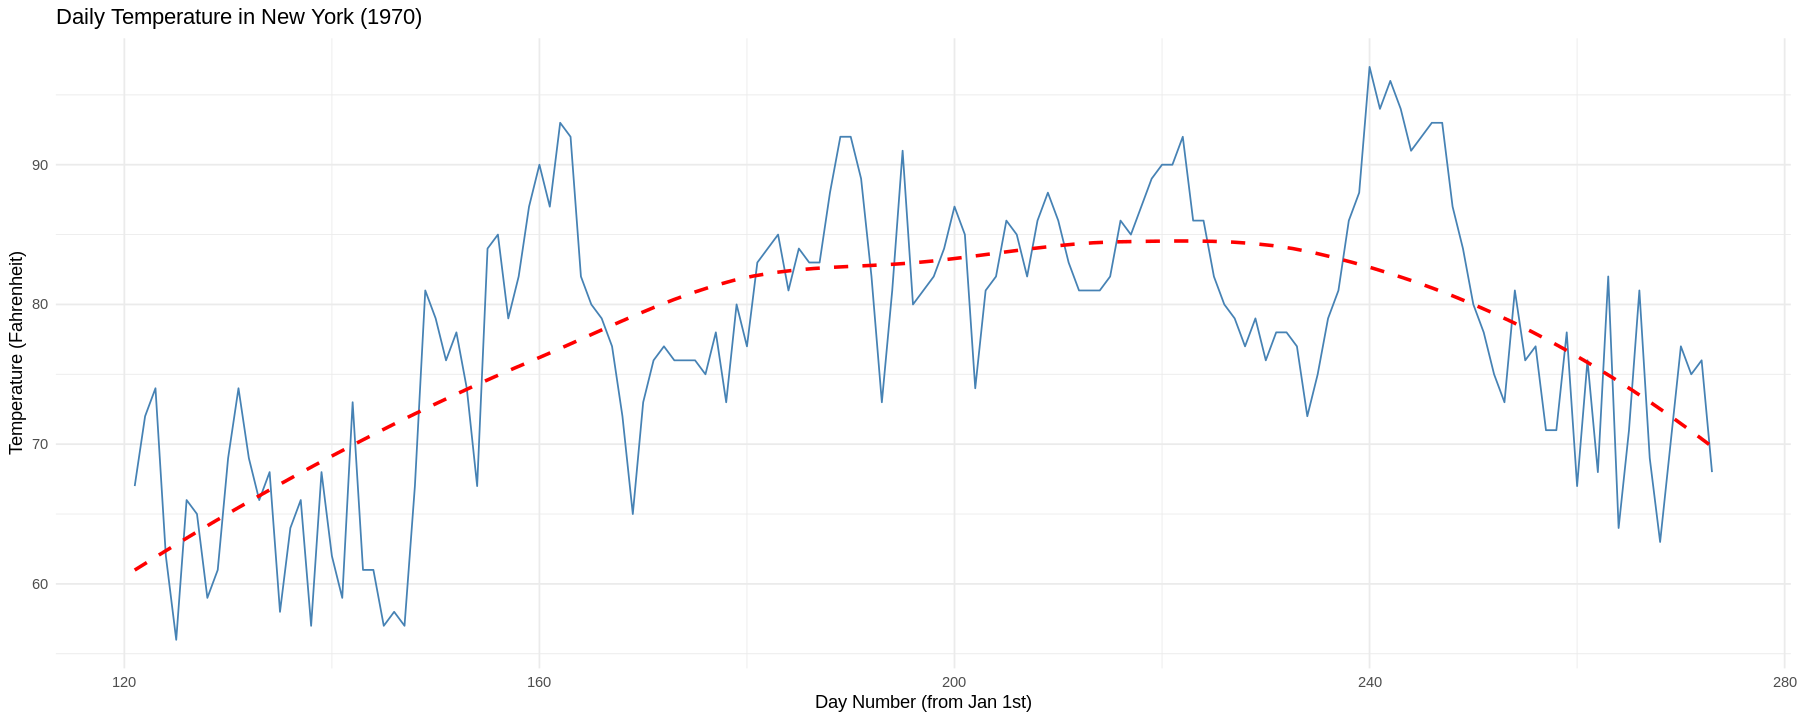

In [ ]:
airquality_df <- airquality %>%
  mutate(Date = as.Date(paste("1970", Month, Day, sep = "-"), format = "%Y-%m-%d"),
         Day_Number = as.numeric(Date - as.Date("1970-01-01")) + 1)

ggplot(airquality_df, aes(x = Day_Number, y = Temp)) +
  geom_line(color = "steelblue") +
  geom_smooth(method = "loess", se = FALSE, color = "red", linetype = "dashed") +
  labs(title = "Daily Temperature in New York (1970)",
       x = "Day Number (from Jan 1st)",
       y = "Temperature (Fahrenheit)") +
  theme_minimal()

## Correlation Function 🧙 (7.5 points🎯)

### 2. Write a function called `Calculate_Correlation` that takes two vectors, X and Y, as input and returns their correlation. You should implement the correlation calculation yourself and **not** use pre-built correlation functions from R packages.

In [ ]:
Calculate_Correlation = function(X,Y)
{
  mean_X <- mean(X)
  mean_Y <- mean(Y)

  covariance <- sum((X - mean_X) * (Y - mean_Y))

  sd_X <- sqrt(sum((X - mean_X)^2))
  sd_Y <- sqrt(sum((Y - mean_Y)^2))

  correlation <- covariance / (sd_X * sd_Y)
  return(correlation)
}

## Autocorrelation 🧙‍♀️ (10 points🎯)

+ In time series data, we often analyze the relationship between a variable at a given time and its past values. This concept is called **Autocorrelation**. It helps us understand how a variable is correlated with itself over different time lags.

#### For this task, we will examine the autocorrelation of temperature with a one-day lag. Specifically, we will:

###3.  Plot the temperature on day *i* against the temperature on day *i-1*.
###4.  Calculate the correlation between these two sets of temperatures using the `Calculate_Correlation` function you implemented earlier. This is referred to as calculating the autocorrelation with a "1 shift" or "lag 1".

`geom_smooth()` using formula = 'y ~ x'


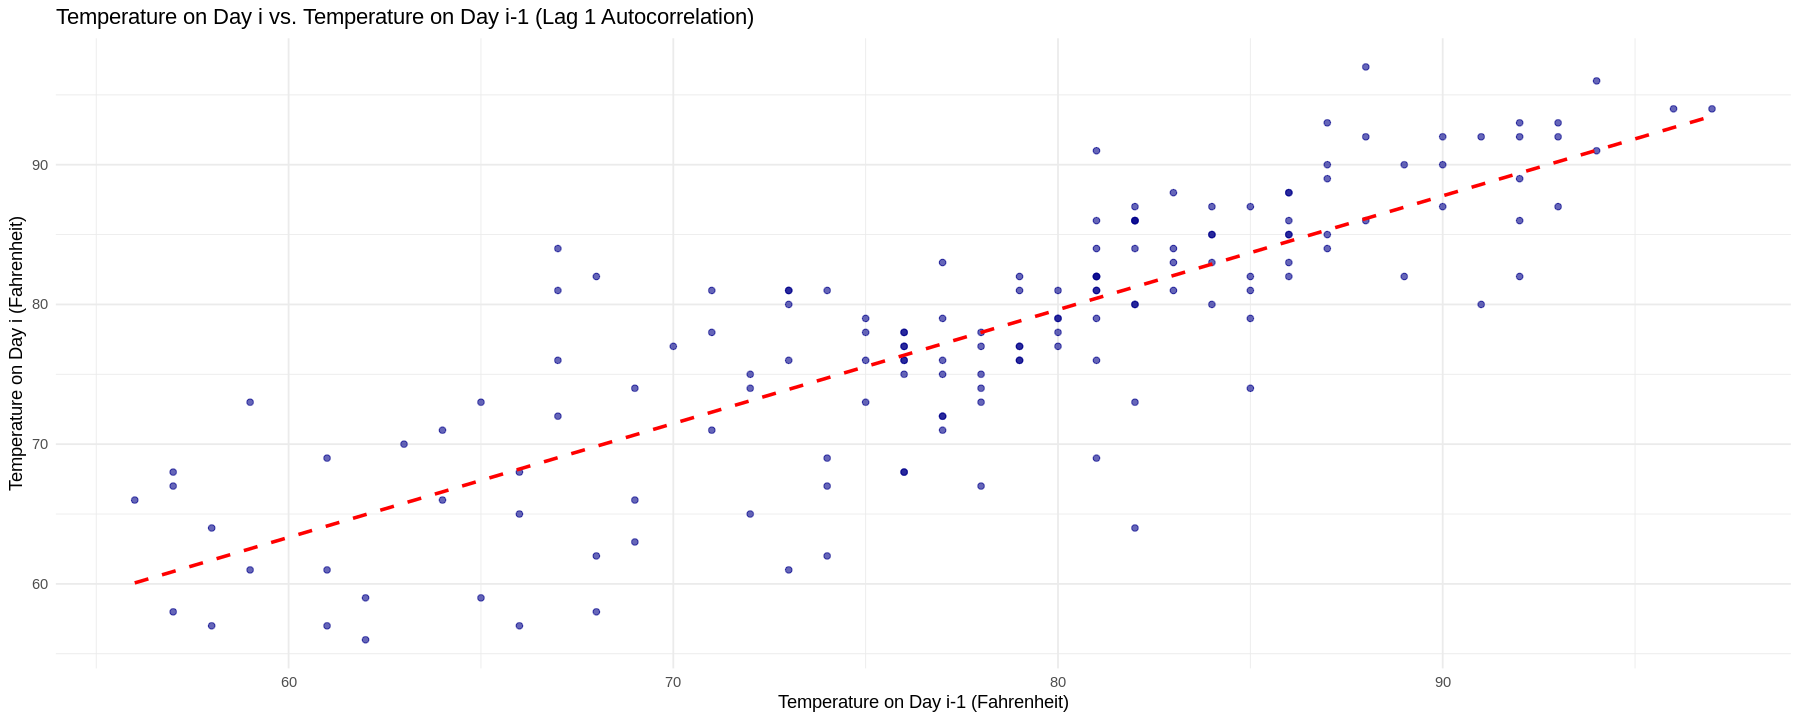

In [ ]:
# Create a lagged temperature variable
lagged_temp_data <- airquality_df %>%
  mutate(Temp_Lag1 = lag(Temp, n = 1)) %>%
  filter(!is.na(Temp_Lag1))

print(ggplot(lagged_temp_data, aes(x = Temp_Lag1, y = Temp)) +
        geom_point(alpha = 0.6, color = "darkblue") +
        geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") +
        labs(title = "Temperature on Day i vs. Temperature on Day i-1 (Lag 1 Autocorrelation)",
             x = "Temperature on Day i-1 (Fahrenheit)",
             y = "Temperature on Day i (Fahrenheit)") +
        theme_minimal())



In [ ]:
correlation_lag1 <- Calculate_Correlation(lagged_temp_data$Temp_Lag1, lagged_temp_data$Temp)

cat('\n')
print(paste("Autocorrelation with a 1-day lag:", correlation_lag1))
cat('\n')


[1] "Autocorrelation with a 1-day lag: 0.815495614474294"



###5. We want to expand on this idead and calcualte correlation for shifts 1 to 100 and plot correlation of temperature with previous days.

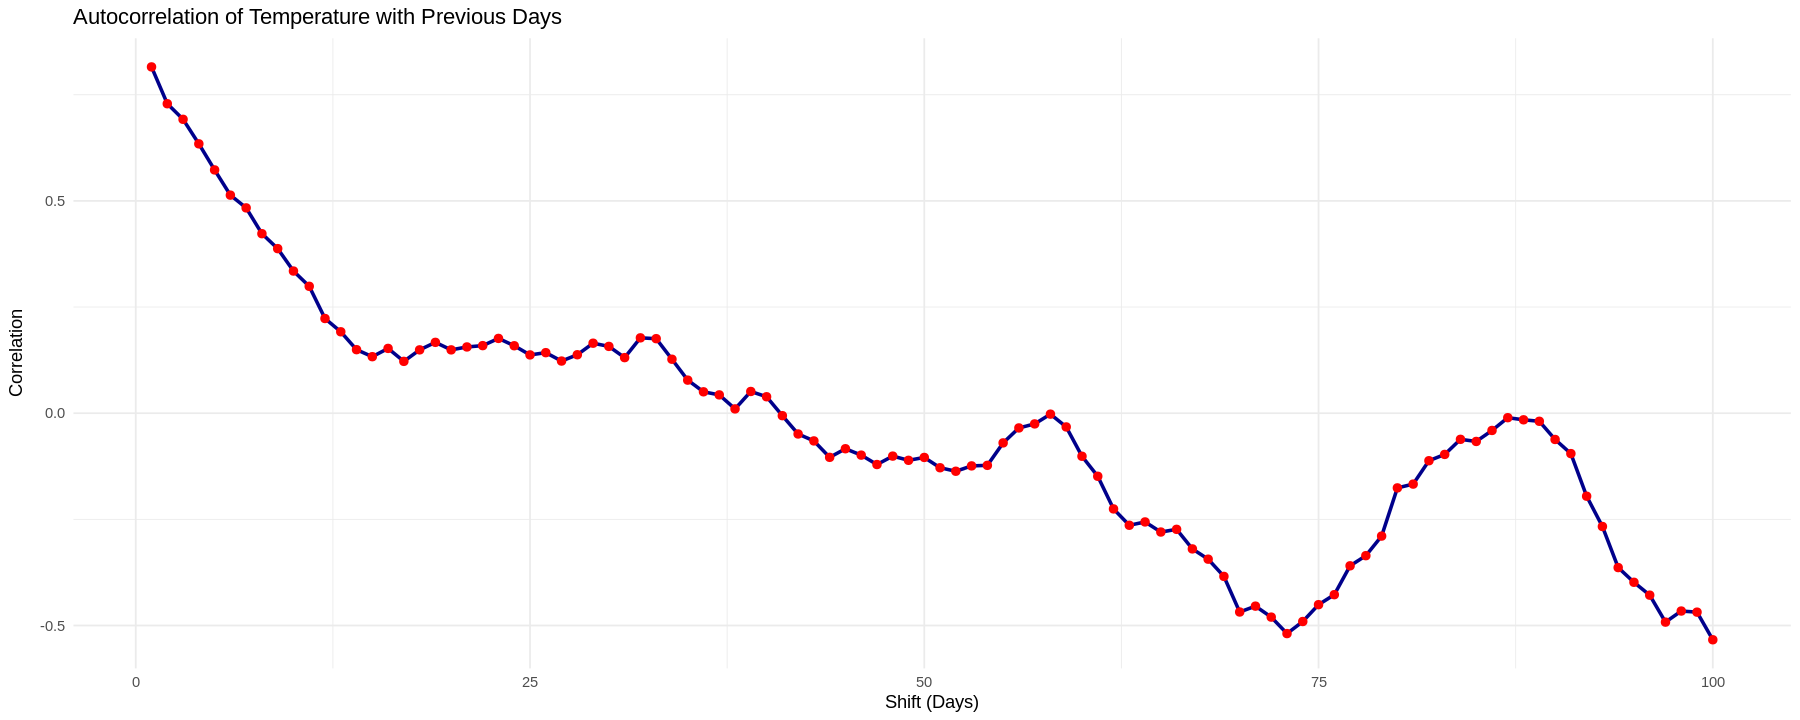

In [ ]:
autocorrelations <- numeric()  # an empty vector

for (shift in 1:100) {
  # Create a lagged temperature variable for the current shift
  lagged_data <- airquality_df %>%
    mutate(Temp_Lag = lag(Temp, n = shift)) %>%
    filter(!is.na(Temp_Lag))

  # Check if there's enough data to calculate correlation
  if (nrow(lagged_data) > 1) {
    # Calculate the correlation using the custom function
    corr <- Calculate_Correlation(lagged_data$Temp_Lag, lagged_data$Temp)
    autocorrelations <- c(autocorrelations, corr)
  } else {
    # If not enough data, append NA or 0
    autocorrelations <- c(autocorrelations, NA)
  }
}

correlation_df <- data.frame(
  Shift = 1:length(autocorrelations),
  Correlation = autocorrelations
)

print(ggplot(correlation_df, aes(x = Shift, y = Correlation)) +
        geom_line(color = "darkblue", linewidth = 1) +
        geom_point(color = "red", size = 2) +
        labs(title = "Autocorrelation of Temperature with Previous Days",
             x = "Shift (Days)",
             y = "Correlation") +
        theme_minimal())

# Question 3 (50 points🎯)
## Conditional Distribution 🤖

For this part we want to locate a robot (WALL-E) in a 10 by 15 grid like maze using it's
sensors.

WALL-E has 4 sensors in its 4 directions that inform it of the presence or absence of a wall in each direction. Each of these 4 sensors has a 10% error. The probability distribution of the result of each sensor is as follows:

$$P(\text{sensor} = 1 | \text{wall} = 1) = 0.9$$
$$P(\text{sensor} = 1 | \text{wall} = 0) = 0.1$$
$$P(\text{sensor} = 0 | \text{wall} = 1) = 0.1$$
$$P(\text{sensor} = 0 | \text{wall} = 0) = 0.9$$

WALL-E is really old and his legs 🦿 are not what they used to be, so even if he chooses to go up, he may go south!!!

given each intended direction, there is a probability of 80% of correctly moving
and 20% moving in the wrong direction (uniformly).
$$P(\text{move} = \text{UP} | \text{intendedDir} = \text{UP}) = 0.8$$
$$P(\text{move} = \text{DOWN} | \text{intendedDir} = \text{UP}) = \frac{0.2}{3}$$
$$P(\text{move} = \text{RIGHT} | \text{intendedDir} = \text{UP}) = \frac{0.2}{3}$$
$$P(\text{move} = \text{LEFT} | \text{intendedDir} = \text{UP}) = \frac{0.2}{3}$$

WALL-E may be old but it has a strong memory 🧠, it stores the history of it's beliefs(the probability of being at each cell each step, more on this later)

WALL-E  wants to find it's location with high accuracy using probabilistic methods and conditional probability to escape from the maze!!! 🌽

To solve this problem, we model it with a set of random variables. Suppose that $X_t$ represents the robot's location after t movements.
Initially the probability of the robot being present in all blocks is equal,
meaning the initial probability for each block (x,y) is:
$$P(X_{0} = (x,y)) = \frac{1}{\text{NUM OF FREE CELLS}}$$

Also, suppose we denote the data read from the sensors at time t by $E_t$ (evidence after t movements 🕵️).



**Common Mistake ✖️**

Random variables $X_{t}$ and $E_{t}$ are vectors!!!

$X_{t}$ shows the location of WALL-E using x,y coordinates for example [3,4].

$E_{t}$ shows the status of WALL-E's sensors for example [0,0,0,1] (only one sensor is on while the others are off)

In our model, $X_{t}$ only depends on $X_{t-1}$ and each $E_t$ also only depends on $X_{t}$ (independent from other random variables).

we can consider a set of random variables:

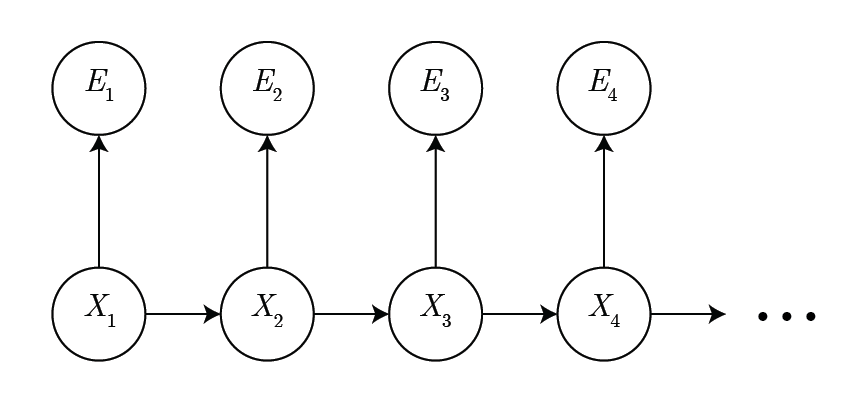


Each arrow indicates the dependence of the variable at the end of the arrow on the variable at the beginning of the arrow.

**What are we looking for? 🔍**

we are looking to estimate $X_t$ from evidences $E_1$ to $E_t$ for each block of the map. So for each step we need to obtain the following probability value:

$$ P(X_{t} | E_1, E_2, ... E_t)$$

This probability can be written as:

$$ { \color{#55cffd} {P(X_t|E_{1:t}) \propto P(X_t, E_{1:t}) \
= \sum_{X_{t-1}} P(X_{t-1}, X_t, E_{1:t}) \
= \sum_{X_{t-1}} P(X_{t-1}, E_{1:t-1}) P(X_t|X_{t-1}) P(E_t|X_t) \
\propto P(E_t|X_t) \sum_{X_{t-1}} P(X_t|X_{t-1}) P(X_{t-1} \mid E_{1:t-1})}}$$

So we will need 3 probabilities:

1. $ P(E_t|X_t) $
2. $ P(X_t|X_{t-1}) $
3. $ P(X_{t-1}, E_{1:t-1}) $

### 0. Theoretical Calculation of Presence Probability (5 points)**

- Assume we have a $2 \times 3$ grid as shown below.


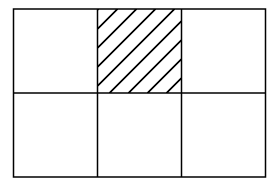

If the robot selects the **DOWN** direction and, after moving, makes the following observation:

$$E_2 = [ \text{UP} = 0, \text{RIGHT} = 0, \text{DOWN} = 1, \text{LEFT} = 1 ]$$

Then, calculate:

$$P(X_2|E_{1:2})$$

(Assume that $P(X_1|E_1)$ is uniformly $0.2$ for all empty cells).

Is the result as expected? Yes — cells whose wall configuration matches the sensor reading will get much higher probability.

🔴 **0. TO DO**

**Given:**
*   **Maze:** A $2 \times 3$ grid.
    ```
    +---+---+---+
    | W |   | W |
    +---+---+---+
    |   | W |   |
    +---+---+---+
    ```
    Representing free cells (F) and walls (W):
    $(1,1)=W, (1,2)=F, (1,3)=W$
    $(2,1)=F, (2,2)=W, (2,3)=F$
    There are 3 free cells: $C = \{(1,2), (2,1), (2,3)\}$.
*   **Initial Belief ($P(X_1|E_1)$):** Uniformly $0.2$ for all empty cells.
    $P(X_1=(r,c)|E_1) = 0.2$ if $(r,c) \in C$, and $0$ otherwise.
*   **Intended Direction:** DOWN.
*   **Movement Probabilities (intended DOWN):**
    *   $P(\text{move} = \text{DOWN} | \text{intendedDir} = \text{DOWN}) = 0.8$
    *   $P(\text{move} = \text{UP} | \text{intendedDir} = \text{DOWN}) = \frac{0.2}{3}$
    *   $P(\text{move} = \text{RIGHT} | \text{intendedDir} = \text{DOWN}) = \frac{0.2}{3}$
    *   $P(\text{move} = \text{LEFT} | \text{intendedDir} = \text{DOWN}) = \frac{0.2}{3}$
    *   **Assumption:** If an intended move leads to a wall, the robot stays in its current cell. The probability mass for moves leading to walls is added to the probability of staying in the current cell.
*   **Observation ($E_2$):** $[\text{UP}=0, \text{RIGHT}=0, \text{DOWN}=1, \text{LEFT}=1]$
*   **Sensor Error ($SENSOR\_ERROR$):** $0.1$
    *   $P(\text{sensor} = 1 | \text{wall} = 1) = 0.9$
    *   $P(\text{sensor} = 1 | \text{wall} = 0) = 0.1$
    *   $P(\text{sensor} = 0 | \text{wall} = 1) = 0.1$
    *   $P(\text{sensor} = 0 | \text{wall} = 0) = 0.9$

**Goal:** Calculate $P(X_2|E_{1:2})$.

**Formula:**
$P(X_2|E_{1:2}) \propto P(E_2|X_2) \sum_{X_1} P(X_2|X_1) P(X_1 \mid E_1)$

---

#### Step 1: Calculate $P(E_2|X_2)$ for each possible $X_2 \in C$.
First, determine the true sensor readings for each free cell $X_2$.

*   **For $X_2 = (1,2)$:**
    *   Adjacent cells: UP $(0,2)$ (Out of bounds/Wall), RIGHT $(1,3)$ (Wall), DOWN $(2,2)$ (Wall), LEFT $(1,1)$ (Wall).
    *   True sensor readings: $[\text{UP}=1, \text{RIGHT}=1, \text{DOWN}=1, \text{LEFT}=1]$.
    *   $P(E_2|X_2=(1,2)) = P(\text{s0}|\text{t1}) \times P(\text{s0}|\text{t1}) \times P(\text{s1}|\text{t1}) \times P(\text{s1}|\text{t1})$
    *   $P(E_2|X_2=(1,2)) = 0.1 \times 0.1 \times 0.9 \times 0.9 = 0.0081$

*   **For $X_2 = (2,1)$:**
    *   Adjacent cells: UP $(1,1)$ (Wall), RIGHT $(2,2)$ (Wall), DOWN $(3,1)$ (Out of bounds/Wall), LEFT $(2,0)$ (Out of bounds/Wall).
    *   True sensor readings: $[\text{UP}=1, \text{RIGHT}=1, \text{DOWN}=1, \text{LEFT}=1]$.
    *   $P(E_2|X_2=(2,1)) = 0.1 \times 0.1 \times 0.9 \times 0.9 = 0.0081$

*   **For $X_2 = (2,3)$:**
    *   Adjacent cells: UP $(1,3)$ (Wall), RIGHT $(2,4)$ (Out of bounds/Wall), DOWN $(3,3)$ (Out of bounds/Wall), LEFT $(2,2)$ (Wall).
    *   True sensor readings: $[\text{UP}=1, \text{RIGHT}=1, \text{DOWN}=1, \text{LEFT}=1]$.
    *   $P(E_2|X_2=(2,3)) = 0.1 \times 0.1 \times 0.9 \times 0.9 = 0.0081$

**Observation:** $P(E_2|X_2)$ is the same for all free cells in this specific scenario.

---

#### Step 2: Calculate $\sum_{X_1} P(X_2|X_1) P(X_1 \mid E_1)$ for each $X_2 \in C$.
We evaluate $P(X_2|X_1)$ for intended DOWN movement from $X_1 \in C$.

*   **For $X_1 = (1,2)$:**
    *   Intended DOWN moves to $(2,2)$ (Wall). The $0.8$ probability mass stays at $(1,2)$.
    *   Wrong moves: UP to $(0,2)$ (Wall), LEFT to $(1,1)$ (Wall), RIGHT to $(1,3)$ (Wall). Each has $0.2/3$ probability. These $3 \times (0.2/3) = 0.2$ probability mass also stays at $(1,2)$.
    *   Therefore, $P(X_2=(1,2)|X_1=(1,2)) = 0.8 + 0.2 = 1$.
    *   All other $P(X_2=(r,c)|X_1=(1,2)) = 0$ for $(r,c) \ne (1,2)$.

*   **For $X_1 = (2,1)$:**
    *   Similarly, all intended moves from $(2,1)$ lead to walls.
    *   Therefore, $P(X_2=(2,1)|X_1=(2,1)) = 1$.
    *   All other $P(X_2=(r,c)|X_1=(2,1)) = 0$ for $(r,c) \ne (2,1)$.

*   **For $X_1 = (2,3)$:**
    *   Similarly, all intended moves from $(2,3)$ lead to walls.
    *   Therefore, $P(X_2=(2,3)|X_1=(2,3)) = 1$.
    *   All other $P(X_2=(r,c)|X_1=(2,3)) = 0$ for $(r,c) \ne (2,3)$.

Now, calculate the sum term for each $X_2$:

*   **For $X_2 = (1,2)$:**
    $\sum_{X_1} P(X_2=(1,2)|X_1) P(X_1 \mid E_1) = P(X_2=(1,2)|X_1=(1,2)) P(X_1=(1,2)|E_1) \quad + \text{ (terms with 0 probability)}$
    $= 1 \times 0.2 = 0.2$

*   **For $X_2 = (2,1)$:**
    $\sum_{X_1} P(X_2=(2,1)|X_1) P(X_1 \mid E_1) = P(X_2=(2,1)|X_1=(2,1)) P(X_1=(2,1)|E_1) \quad + \text{ (terms with 0 probability)}$
    $= 1 \times 0.2 = 0.2$

*   **For $X_2 = (2,3)$:**
    $\sum_{X_1} P(X_2=(2,3)|X_1) P(X_1 \mid E_1) = P(X_2=(2,3)|X_1=(2,3)) P(X_1=(2,3)|E_1) \quad + \text{ (terms with 0 probability)}$
    $= 1 \times 0.2 = 0.2$

---

#### Step 3: Calculate $P(X_2|E_{1:2}) \propto P(E_2|X_2) \times (\text{sum term})$

*   **For $X_2 = (1,2)$:** $0.0081 \times 0.2 = 0.00162$
*   **For $X_2 = (2,1)$:** $0.0081 \times 0.2 = 0.00162$
*   **For $X_2 = (2,3)$:** $0.0081 \times 0.2 = 0.00162$

---

#### Step 4: Normalize the probabilities.
Total unnormalized probability $= 0.00162 + 0.00162 + 0.00162 = 0.00486$

*   **Normalized $P(X_2|E_{1:2}=(1,2))$:** $0.00162 / 0.00486 = 1/3$
*   **Normalized $P(X_2|E_{1:2}=(2,1))$:** $0.00162 / 0.00486 = 1/3$
*   **Normalized $P(X_2|E_{1:2}=(2,3))$:** $0.00162 / 0.00486 = 1/3$

---

#### Result:

$P(X_2=(1,2)|E_{1:2}) = 1/3$

$P(X_2=(2,1)|E_{1:2}) = 1/3$

$P(X_2=(2,3)|E_{1:2}) = 1/3$


### Basic definitions
This section contains the map, list of movements and constant values.
+ 🔴 **You do not need to change this section.**

+ The function `generate_directions` generates a sequence of moves specified by the strings u, l, d, r and outputs the list of moves.

In [ ]:
generate_directions <- function(map, start_pos = c(2, 3), n = 300, valid_ratio = 0.9) {
  directions <- c("u", "d", "l", "r")
  moves <- list(u = c(-1, 0), d = c(1, 0), l = c(0, -1), r = c(0, 1))

  pos <- start_pos
  chosen_dirs <- character(0)
  valid_moves <- 0

  NUM_ROWS <- nrow(map)
  NUM_COLS <- ncol(map)

  while (length(chosen_dirs) < n) {
    dir <- sample(directions, 1)
    new_pos <- pos + moves[[dir]]

    if (new_pos[1] < 1 || new_pos[1] > NUM_ROWS ||
        new_pos[2] < 1 || new_pos[2] > NUM_COLS ||
        map[new_pos[1], new_pos[2]] == 1) {
      if (runif(1) > valid_ratio) {
        chosen_dirs <- c(chosen_dirs, dir)
      }
    } else {
      pos <- new_pos
      chosen_dirs <- c(chosen_dirs, dir)
      valid_moves <- valid_moves + 1
    }
  }

  return(chosen_dirs)
}

In [ ]:
map <- matrix(c(
  1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
  1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
  1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
  1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
  1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
  1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
  1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
  1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
  1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
  1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
), nrow = 15, ncol = 10) %>% t()

dim = dim(map)

NUM_ROWS = dim[1]
NUM_COLS = dim[2]
SENSOR_ERROR = 0.1
MOVE_ERROR = 0.2
INITIAL_POS = c(2,3)

# List of robot movements Generated by a function. You can change the percentage of moves that are valid (do not hit the wall) and the number of moves.
# The output is a list of 4 letters u, d, l, r.
chosen_dirs <- generate_directions(map, start_pos = INITIAL_POS, n = 300, valid_ratio = 0.9)

actions <- list(
  u = c(y = -1, x = 0),
  d = c(y = 1, x = 0),
  l = c(y = 0, x = -1),
  r = c(y = 0, x = 1)
)

action_names <- names(actions)


###  1. Finding The Evidence!!! 🔍
+ a function that takes WALL-E's current position and the map and returns the values of the top, right, bottom, and left sensors (4 element list).
These are the values of WALL-E's sensors (or evidences of our model).

+ 🔴 **You do not need to change this section.**


In [ ]:
sensor <- function(map, current_pos) {

  get_single_reading <- function(target_pos) {

    is_wall_present <- FALSE
    if (map[target_pos[1], target_pos[2]] == 1) {
      is_wall_present <- TRUE
    }
    true_value <- ifelse(is_wall_present, 1, 0)

    random_chance <- runif(1)
    if (random_chance <= (1 - SENSOR_ERROR)) {
      return(true_value)
    }
    else {
      return(1 - true_value)
    }
  }

  pos_up <- current_pos + actions$u
  pos_down <- current_pos + actions$d
  pos_left <- current_pos + actions$l
  pos_right <- current_pos + actions$r

  reading_up <- get_single_reading(pos_up)
  reading_down <- get_single_reading(pos_down)
  reading_left <- get_single_reading(pos_left)
  reading_right <- get_single_reading(pos_right)

  return(list(u = reading_up, r = reading_right, d = reading_down, l = reading_left))
}

### 2. **TO-DO:** Find WALL-E's Next Position 🔍 (10 points🎯)
+ Write a function that takes WALL-E's current position and it's chosen direction and returns the position after the movement.

In [ ]:
move <- function(map, current_pos, chosen_dir) {
  NUM_ROWS <- nrow(map)
  NUM_COLS <- ncol(map)

  # Get the change in coordinates for the chosen direction
  delta_y <- actions[[chosen_dir]][["y"]]
  delta_x <- actions[[chosen_dir]][["x"]]

  new_pos <- current_pos + c(delta_y, delta_x)

  # Check for out-of-bounds or wall collision
  if (new_pos[1] < 1 || new_pos[1] > NUM_ROWS ||
      new_pos[2] < 1 || new_pos[2] > NUM_COLS ||
      map[new_pos[1], new_pos[2]] == 1) {
    return(current_pos)
  } else {
    return(new_pos)
  }
}

### 3.  **TO-DO:** Calculating $ P(E_t|X_t) $ 🧮 (10 points🎯)
+ 3.1. Theoritically calculate the above probability using $E_t = [0,1,0,1]$ and $X_t = [3,4]$ for the map given above.
+ 3.2. Write a function that takes the last evidence ($E_t$) and WALL-E's position ($X_t$) and return the probability $ P(E_t|X_t) $.
+ 3.3. Check your 3.1. answer using 3.2. function

🔴 **3.1 TO DO**

In [ ]:
# Theoretical calculation for X_t=(3,4) and E_t=[UP=0, RIGHT=1, DOWN=0, LEFT=1]:
# Map around (3,4) is:
# UP (2,4): Free (0)
# RIGHT (3,5): Free (0)
# DOWN (4,4): Free (0)
# LEFT (3,3): Wall (1)  <-- Corrected this from 'Free'

# P(UP=0|True UP=0) = 1 - SENSOR_ERROR = 0.9
# P(RIGHT=1|True RIGHT=0) = SENSOR_ERROR = 0.1
# P(DOWN=0|True DOWN=0) = 1 - SENSOR_ERROR = 0.9
# P(LEFT=1|True LEFT=1) = 1 - SENSOR_ERROR = 0.9  <-- Corrected this from SENSOR_ERROR

theoretical_prob = 0.9 * 0.1 * 0.9 * 0.9
print(paste("Theoretical P(E_t|X_t) for E_t=[0,1,0,1] and X_t=[3,4]:", theoretical_prob))

[1] "Theoretical P(E_t|X_t) for E_t=[0,1,0,1] and X_t=[3,4]: 0.0729"


3.2. **$ P(E_t|X_t) $ Function**

In [ ]:
cal_observation_prob <- function(map, xt, et) {
  # et: List of sensor readings (u, r, d, l)
  # xt: Current position (y, x)

  NUM_ROWS <- nrow(map)
  NUM_COLS <- ncol(map)

  prob <- 1

  # Define relative positions for sensors
  sensor_dirs <- list(
    u = c(-1, 0),
    r = c(0, 1),
    d = c(1, 0),
    l = c(0, -1)
  )

  # Iterate through each sensor reading
  for (dir_name in names(et)) {
    sensor_reading <- et[[dir_name]] # Observed sensor value (0 or 1)
    delta_pos <- sensor_dirs[[dir_name]]
    check_pos <- xt + delta_pos # Position to check for wall

    # Determine if there's a true wall at check_pos
    is_wall_true <- FALSE
    # Check bounds first, if out of bounds, it's considered a wall
    if (check_pos[1] < 1 || check_pos[1] > NUM_ROWS ||
        check_pos[2] < 1 || check_pos[2] > NUM_COLS) {
      is_wall_true <- TRUE
    } else if (map[check_pos[1], check_pos[2]] == 1) {
      is_wall_true <- TRUE
    }

    current_sensor_prob <- 0
    # Calculate probability for this single sensor
    if (is_wall_true) {
      # If there's a true wall
      if (sensor_reading == 1) {
        current_sensor_prob <- (1 - SENSOR_ERROR) # P(sensor=1|wall=1) = 0.9
      } else {
        current_sensor_prob <- SENSOR_ERROR      # P(sensor=0|wall=1) = 0.1
      }
    } else {
      # If there's no true wall (free space)
      if (sensor_reading == 1) {
        current_sensor_prob <- SENSOR_ERROR      # P(sensor=1|wall=0) = 0.1
      } else {
        current_sensor_prob <- (1 - SENSOR_ERROR) # P(sensor=0|wall=0) = 0.9
      }
    }
    prob <- prob * current_sensor_prob
  }
  return(prob)
}

In [ ]:
xt_verify <- c(3, 4)
et_verify <- list(u = 0, r = 1, d = 0, l = 1) # Observation E_t = [0,1,0,1]

# Call the cal_observation_prob function with map, xt = (3,4), and et = [0,1,0,1]
calculated_prob <- cal_observation_prob(map, xt_verify, et_verify)

print(paste("Calculated P(E_t|X_t) using function:", calculated_prob))

print(paste("Theoretical P(E_t|X_t) for E_t=[0,1,0,1] and X_t=[3,4]:",theoretical_prob))

[1] "Calculated P(E_t|X_t) using function: 0.0729"
[1] "Theoretical P(E_t|X_t) for E_t=[0,1,0,1] and X_t=[3,4]: 0.0729"


### 4. **TO-DO:** Calculating $ P(X_t|X_{t-1}) $ 🧮 (10 points🎯)
+ Write a function that takes $X_t$, $X_{t-1}$, and the direction chosen by the WALL-E and outputs the probability that WALL-E will go from $X_{t-1}$ to $X_t$ given the input direction.

+ For example, `f((3,4), (3,5) , 'u')` is equal to the probability that WALL-E will go from house (3,5) to (3,4) while choosing the up direction.

+ Note: If $X_{t-1}$ were a wall, we would return 0.

+ Note: If $X_{t-1}$ were not a neighbor of $X_t$ or $X_t$ itself, it is clearly impossible for the robot to go from $X_{t-1}$ to $X_t$. So we would return 0.

+ Note: If $X_t$ were a wall, we would return 0.

In [ ]:
cal_move_prob <- function(map, xt, xt_minus_1, chosen_dir) {
  NUM_ROWS <- nrow(map)
  NUM_COLS <- ncol(map)

  # Check if X_t or X_{t-1} is a wall. If so, probability is 0.
  if (map[xt_minus_1[1], xt_minus_1[2]] == 1 || map[xt[1], xt[2]] == 1) {
    return(0)
  }

  # Calculate potential destination for correct move
  intended_delta_y <- actions[[chosen_dir]][["y"]]
  intended_delta_x <- actions[[chosen_dir]][["x"]]
  intended_dest <- xt_minus_1 + c(intended_delta_y, intended_delta_x)

  # Check if the intended move leads to a wall or out of bounds from xt_minus_1
  intended_move_blocked <- FALSE
  if (intended_dest[1] < 1 || intended_dest[1] > NUM_ROWS ||
      intended_dest[2] < 1 || intended_dest[2] > NUM_COLS ||
      map[intended_dest[1], intended_dest[2]] == 1) {
    intended_move_blocked <- TRUE
  }

  # Probability of reaching xt from xt_minus_1
  if (all(xt == xt_minus_1)) { # Robot stays in the same cell
    prob_to_stay <- 0
    if (intended_move_blocked) {
        prob_to_stay <- prob_to_stay + (1 - MOVE_ERROR) # The 0.8 for correct move, if blocked
    }

    # Also add probability of wrong moves that get blocked, causing the robot to stay.
    wrong_directions <- setdiff(action_names, chosen_dir)
    for (wrong_dir in wrong_directions) {
        wrong_delta_y <- actions[[wrong_dir]][["y"]]
        wrong_delta_x <- actions[[wrong_dir]][["x"]]
        wrong_dest <- xt_minus_1 + c(wrong_delta_y, wrong_delta_x)

        wrong_move_blocked <- FALSE
        if (wrong_dest[1] < 1 || wrong_dest[1] > NUM_ROWS ||
            wrong_dest[2] < 1 || wrong_dest[2] > NUM_COLS ||
            map[wrong_dest[1], wrong_dest[2]] == 1) {
            wrong_move_blocked <- TRUE
        }

        if (wrong_move_blocked) {
            prob_to_stay <- prob_to_stay + (MOVE_ERROR / 3)
        }
    }
    return(prob_to_stay)

  } else { # Robot moves to a different cell
    prob_move <- 0

    # Case 1: Correct move (0.8 probability) leads to xt
    if (!intended_move_blocked && all(intended_dest == xt)) {
      prob_move <- prob_move + (1 - MOVE_ERROR)
    }

    # Case 2: Wrong move (0.2 probability spread over 3 directions) leads to xt
    wrong_directions <- setdiff(action_names, chosen_dir)
    for (wrong_dir in wrong_directions) {
      wrong_delta_y <- actions[[wrong_dir]][["y"]]
      wrong_delta_x <- actions[[wrong_dir]][["x"]]
      wrong_dest <- xt_minus_1 + c(wrong_delta_y, wrong_delta_x)

      wrong_move_blocked <- FALSE
        if (wrong_dest[1] < 1 || wrong_dest[1] > NUM_ROWS ||
            wrong_dest[2] < 1 || wrong_dest[2] > NUM_COLS ||
            map[wrong_dest[1], wrong_dest[2]] == 1) {
            wrong_move_blocked <- TRUE
        }

      if (!wrong_move_blocked && all(wrong_dest == xt)) {
        prob_move <- prob_move + (MOVE_ERROR / 3)
      }
    }
    return(prob_move)
  }
}

### 5. **TO-DO:** Main program loop 🔁 (10 points🎯)

+ Write the main loop using the model's formula provided to calculate $P(X_t| E_{1:t})$
+ Don't forget to normalize !! you can use the normalize function below to normalize the belief.

Complete the `model` function so that it returns a binary list of the model's beliefs and the robot's actual positions by taking the map and the chosen directions of the robot:

`return (list(beliefs = beliefs, real_pos = real_pos))`

#### Initializing
Initializing the belief list and the WALL-E's actual position
+ Note: The `beliefs` is a list to store WALL-E's belief about its location at each time step. Each element in this list will be a matrix representing the probability distribution of the robot being in each cell of the grid (belief). Initially, we add a uniform distribution to it.

❗ Beliefs is used to simulate our model and real postions is used to simulate real tracking of WALL-E. we can find our model's perfomance by comparing
beliefs and real positions.

In [ ]:
normalize <- function(m) {
  total_sum <- sum(m)
  normalized_m <- m / total_sum
  return(normalized_m)
}

In [ ]:
model <- function(map, chosen_dirs) {

  current_pos <- INITIAL_POS

  real_pos <- list()
  beliefs <- list()

  # Function to initialize probabilities uniformly over free cells
  initial_probs <- function(map) {
    num_zeros <- sum(map == 0)
    if (num_zeros == 0) {
      return(matrix(0, nrow = nrow(map), ncol = ncol(map)))
    }
    replacement_value <- 1 / num_zeros
    output_mat <- ifelse(map == 0, replacement_value, 0)
    return(output_mat)
  }

  # Initialize belief (P(X0)) and real position
  current_belief <- initial_probs(map)
  beliefs <- append(beliefs, list(current_belief))
  real_pos <- append(real_pos, list(current_pos))

  # Main program loop
  for (t in 1:length(chosen_dirs)) {
    dir_t <- chosen_dirs[t]

    # Calculate P(Xt | E1:t-1)
    # This is equivalent to sum over Xt-1 of P(Xt | Xt-1) * P(Xt-1 | E1:t-1)
    predicted_belief <- matrix(0, nrow = NUM_ROWS, ncol = NUM_COLS)
    for (r_t in 1:NUM_ROWS) {
      for (c_t in 1:NUM_COLS) {
        if (map[r_t, c_t] == 0) { # Only calculate for free cells
          xt_candidate <- c(r_t, c_t)
          sum_term <- 0
          for (r_prev in 1:NUM_ROWS) {
            for (c_prev in 1:NUM_COLS) {
              if (map[r_prev, c_prev] == 0) { # Only consider previous free cells
                xt_minus_1_candidate <- c(r_prev, c_prev)
                # P(Xt | Xt-1) is cal_move_prob(Xt, Xt-1, chosen_dir)
                # P(Xt-1 | E1:t-1) is the current_belief at Xt-1
                sum_term <- sum_term + cal_move_prob(map, xt_candidate, xt_minus_1_candidate, dir_t) * current_belief[r_prev, c_prev]
              }
            }
          }
          predicted_belief[r_t, c_t] <- sum_term
        }
      }
    }

    # Simulate actual robot movement and sensor reading for the current step
    actual_next_pos <- move(map, current_pos, dir_t)
    et <- sensor(map, actual_next_pos) # Evidence Et for the new actual position

    # 2. Update Step: Calculate P(Xt | E1:t) = P(Et | Xt) * P(Xt | E1:t-1)
    new_belief <- matrix(0, nrow = NUM_ROWS, ncol = NUM_COLS)
    for (r_t in 1:NUM_ROWS) {
      for (c_t in 1:NUM_COLS) {
        if (map[r_t, c_t] == 0) {
          xt_candidate <- c(r_t, c_t)
          # P(Et | Xt) is cal_observation_prob(Et, Xt)
          # P(Xt | E1:t-1) is predicted_belief at Xt
          new_belief[r_t, c_t] <- cal_observation_prob(map, xt_candidate, et) * predicted_belief[r_t, c_t]
        }
      }
    }

    # Normalize the new belief
    new_belief <- normalize(new_belief)

    # Update current belief and real position for next iteration
    current_belief <- new_belief
    current_pos <- actual_next_pos

    beliefs <- append(beliefs, list(current_belief))
    real_pos <- append(real_pos, list(current_pos))
  }

  return(list(beliefs = beliefs, real_pos = real_pos))
}

In [ ]:
result <- model(map, chosen_dirs)
beliefs <- result$beliefs
real_pos = result$real_pos

### 6. Visualization 🎨

The following function is used to draw the Maze Heatmap.
+ 🔴 **You do not need to change this section.**

In [ ]:
plot_belief_map <- function(map, belief, current_pos) {
  rows <- nrow(map)
  cols <- ncol(map)
  max_idx <- which.max(belief)
  max_belief_pos <- arrayInd(max_idx, .dim = c(rows, cols))
  plot(NA, xlim = c(0, cols), ylim = c(0, rows), type = "n",
       xlab = "", ylab = "", main = "Robot Belief State",
       xaxs = "i", yaxs = "i", xaxt = 'n', yaxt = 'n', asp = 1)
  max_b <- max(belief)
  norm_belief <- if (max_b > 0) belief / max_b else belief
  col_palette <- colorRampPalette(c("#F7FBFF", "#6BAED6", "#08306B"))(101)
  for (r in 1:rows) {
    for (c in 1:cols) {
      xleft <- c - 1
      ybottom <- rows - r
      xright <- c
      ytop <- rows - r + 1

      if (map[r, c] == 1) {
        rect(xleft, ybottom, xright, ytop, col = "grey20", border = "grey50")
      } else {
        color_idx <- floor(norm_belief[r, c] * 100) + 1
        rect(xleft, ybottom, xright, ytop, col = col_palette[color_idx], border = "grey50")
      }
    }
  }
  rect(max_belief_pos[2] - 1, rows - max_belief_pos[1],
       max_belief_pos[2], rows - max_belief_pos[1] + 1,
       border = "#00FFFF", lwd = 4)
  text(x = current_pos[2] - 0.5, y = rows - current_pos[1] + 0.5,
       labels = "X", col = "red", font = 2, cex = 2)
}

### 7. Results 🚀
Using lists `beliefs` and `real_pos`, we'll draw the maze at each step.
+ 🔴 **You do not need to change this section.**

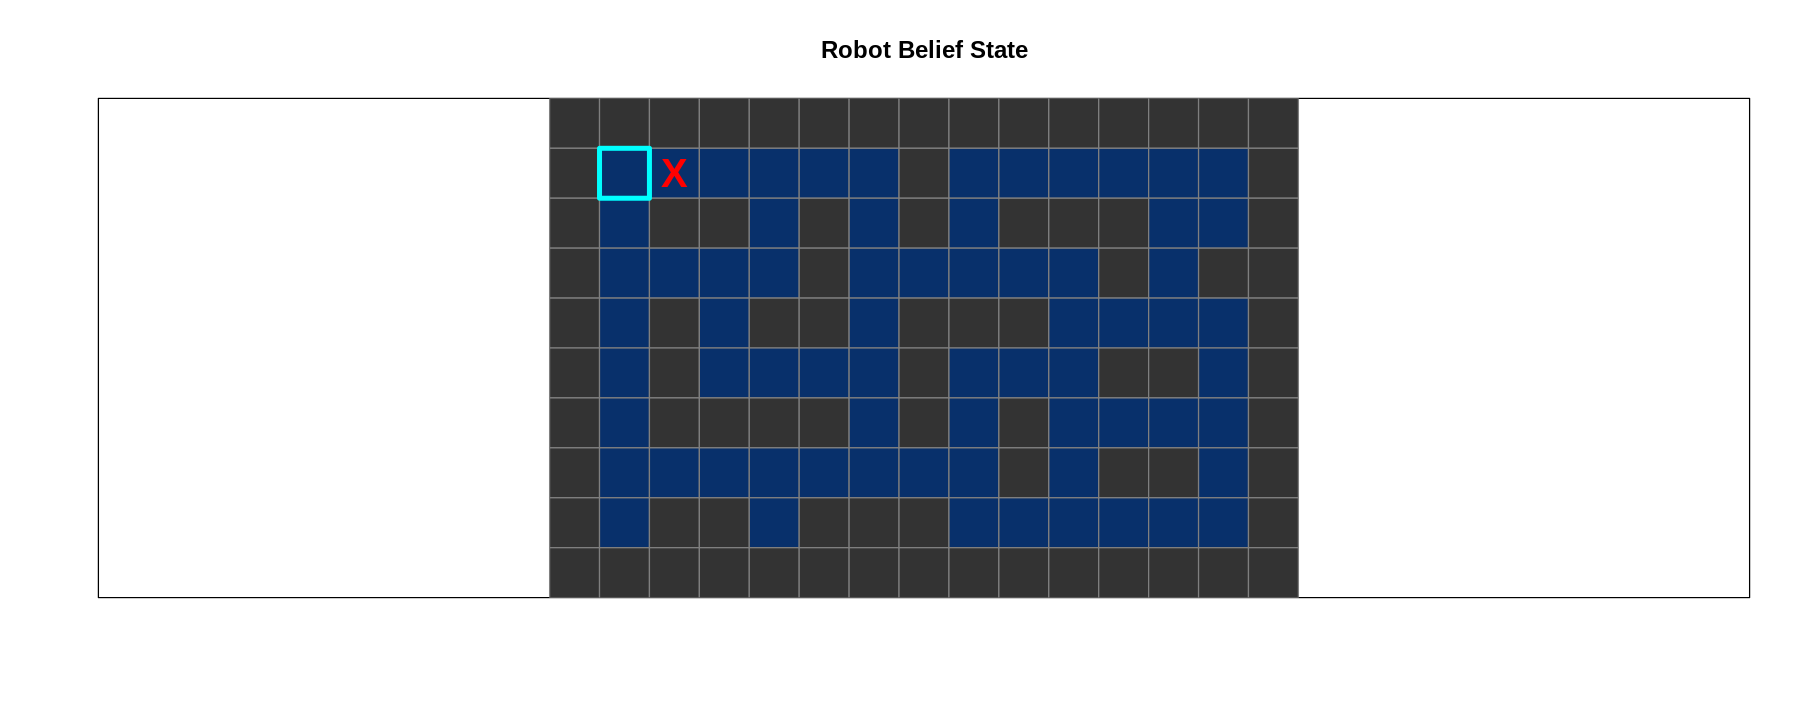

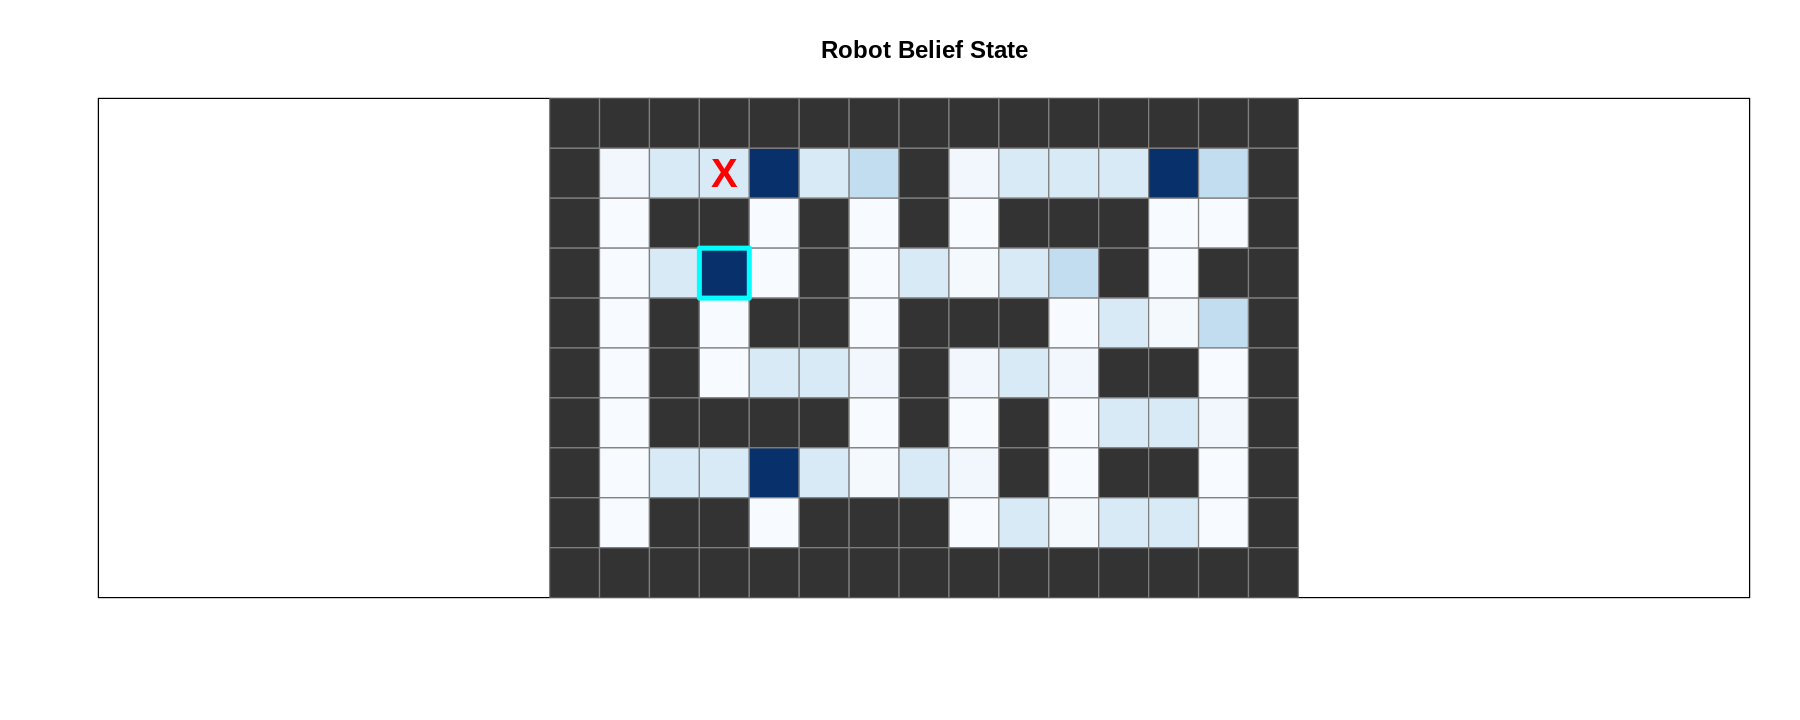

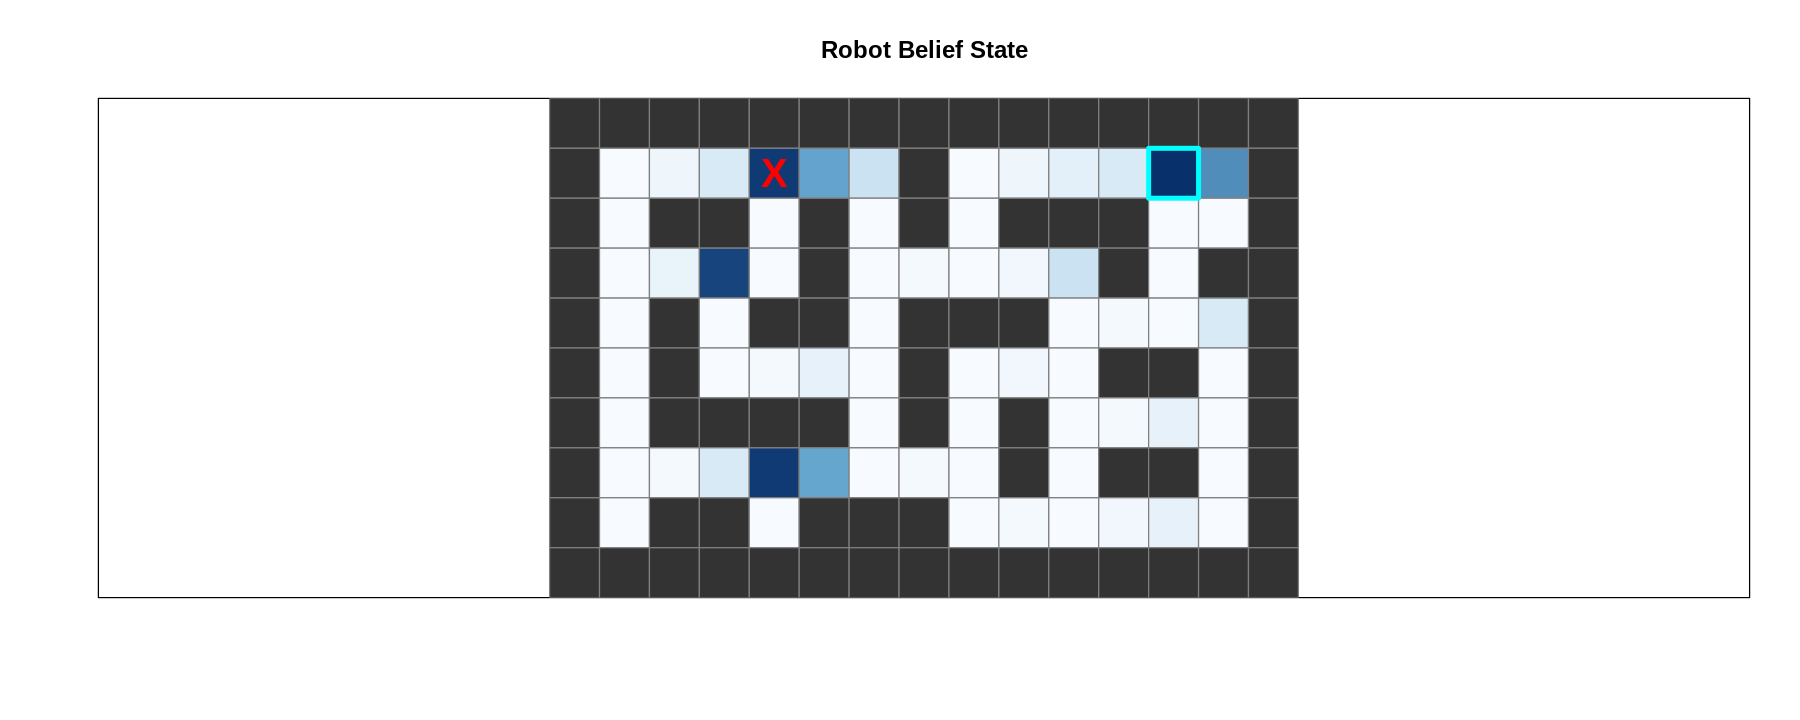

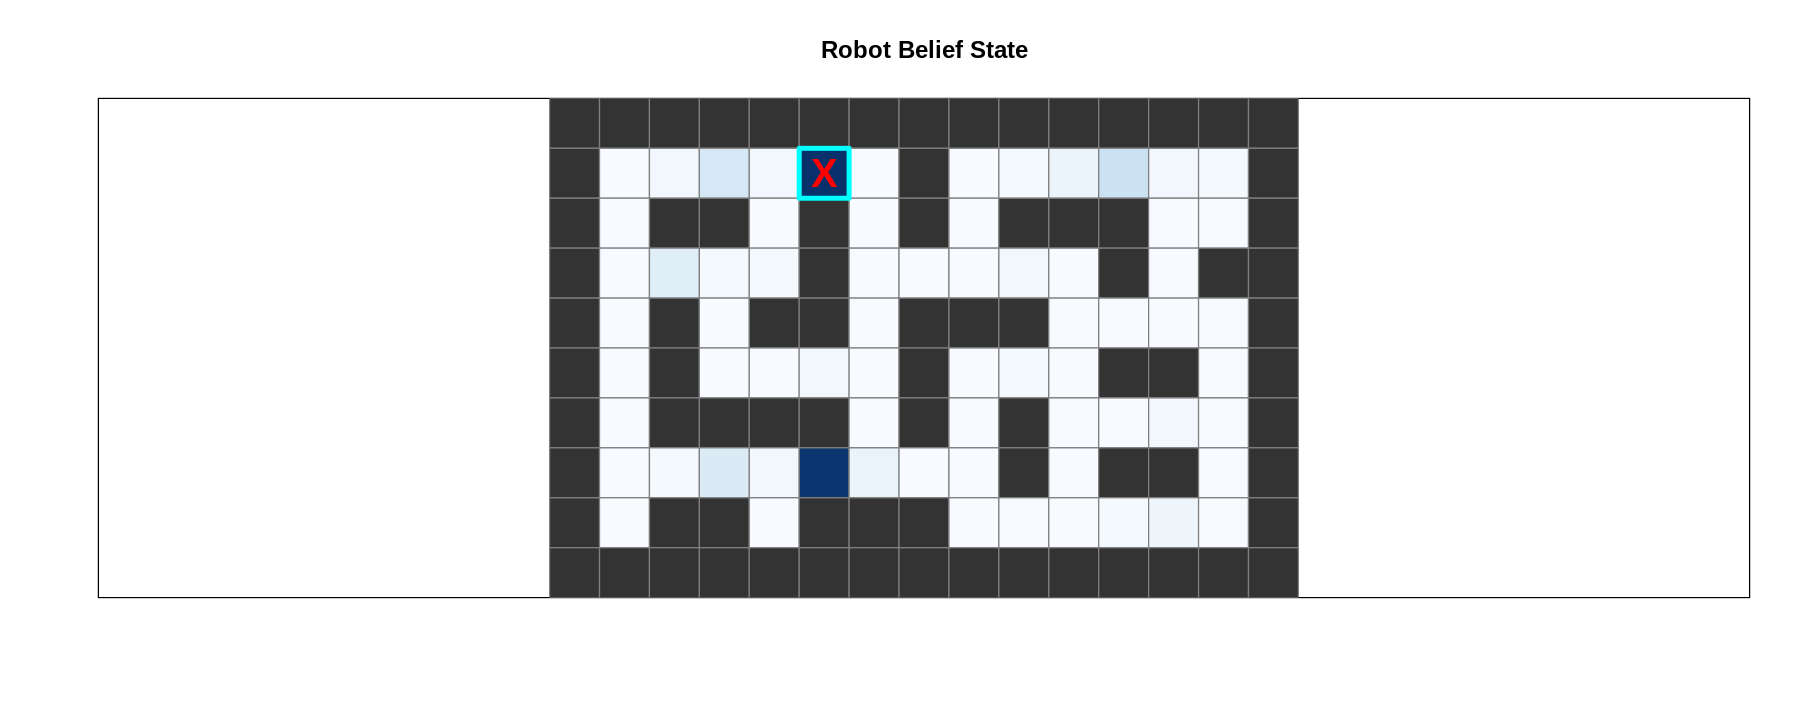

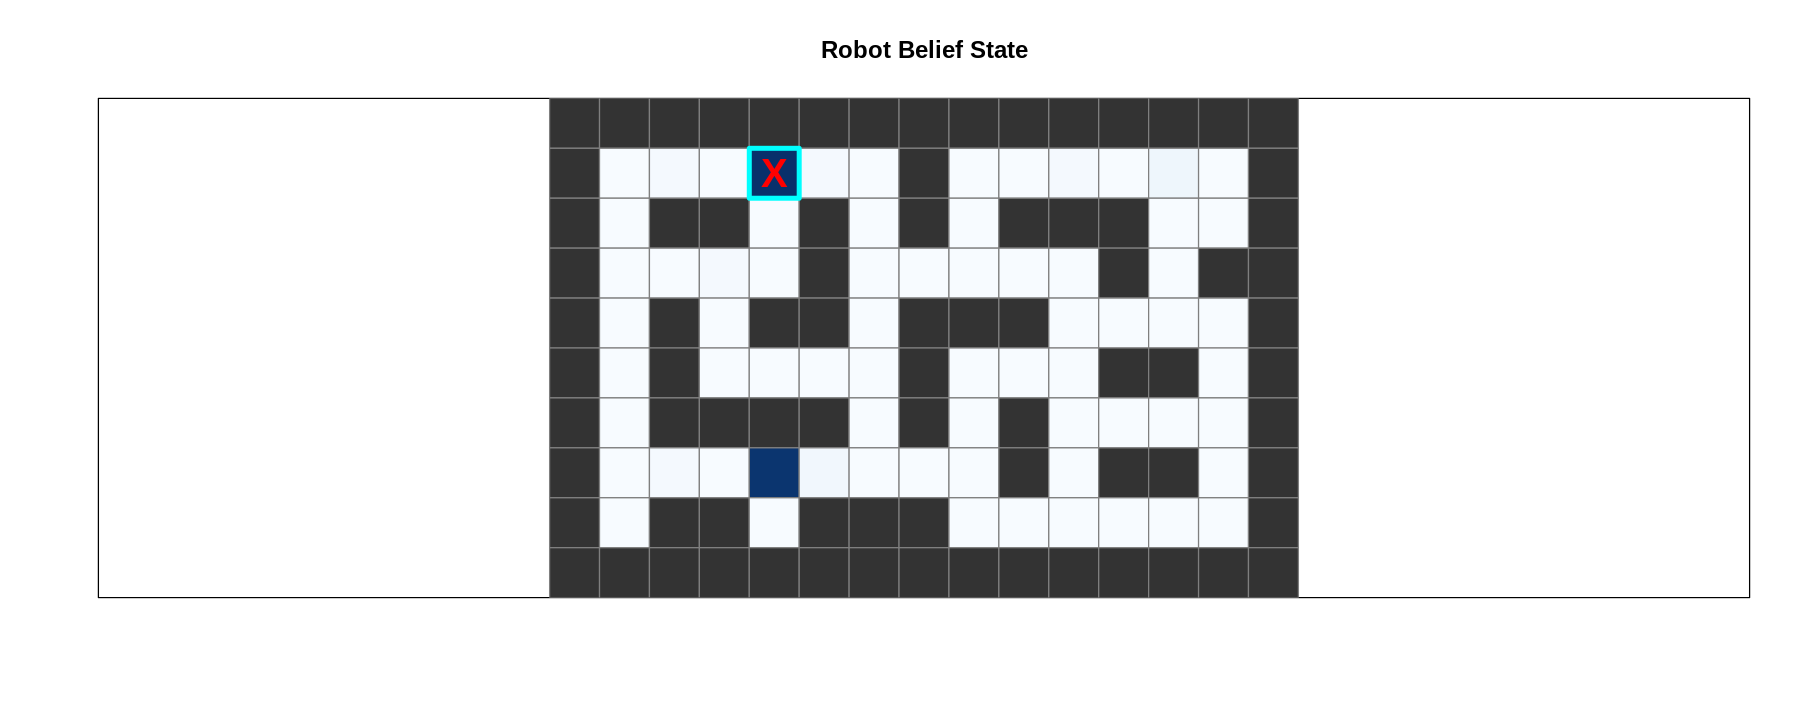

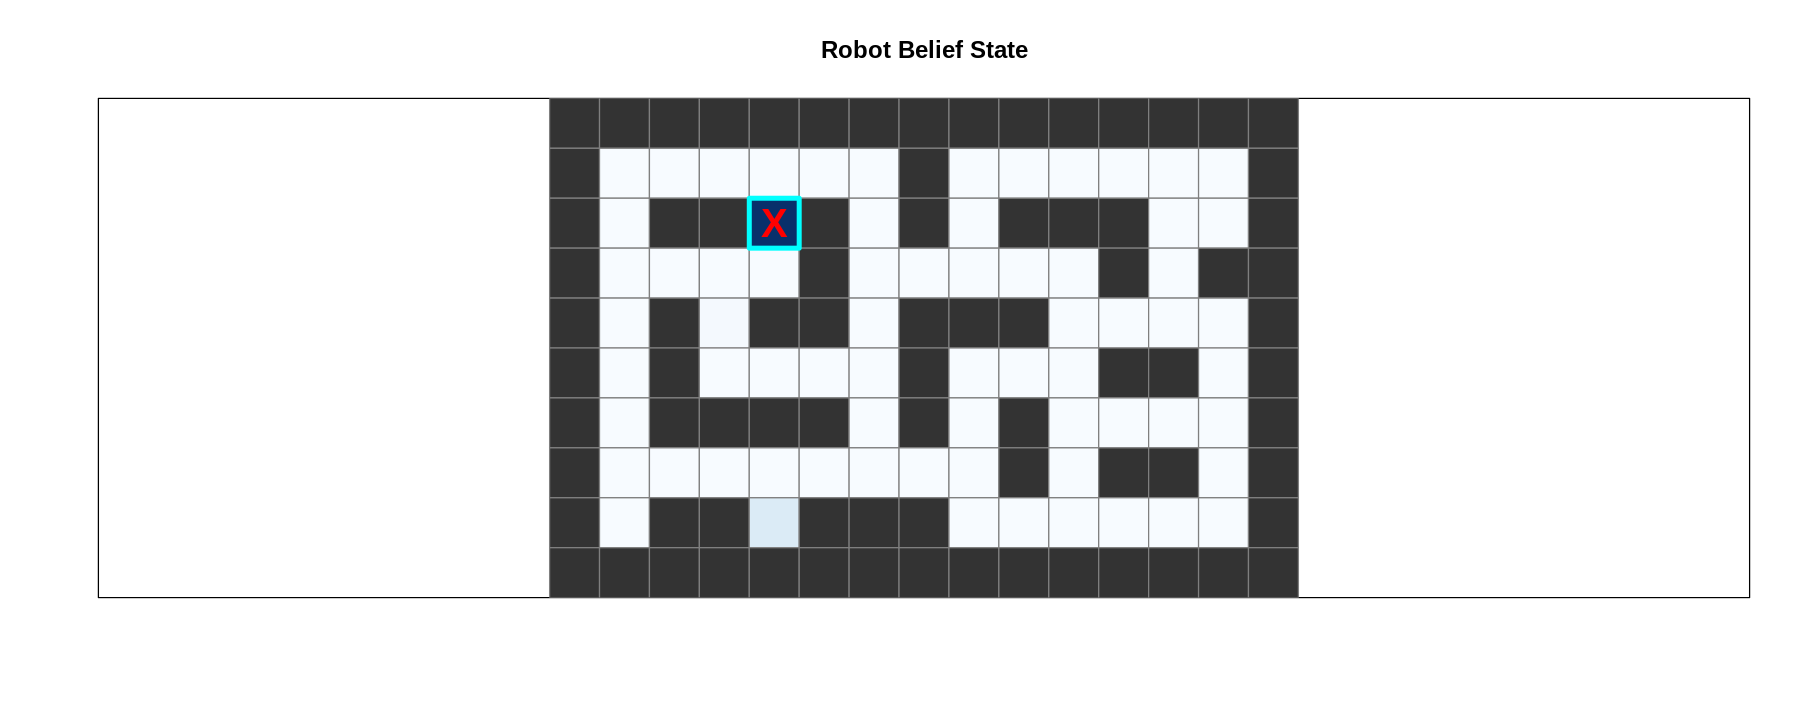

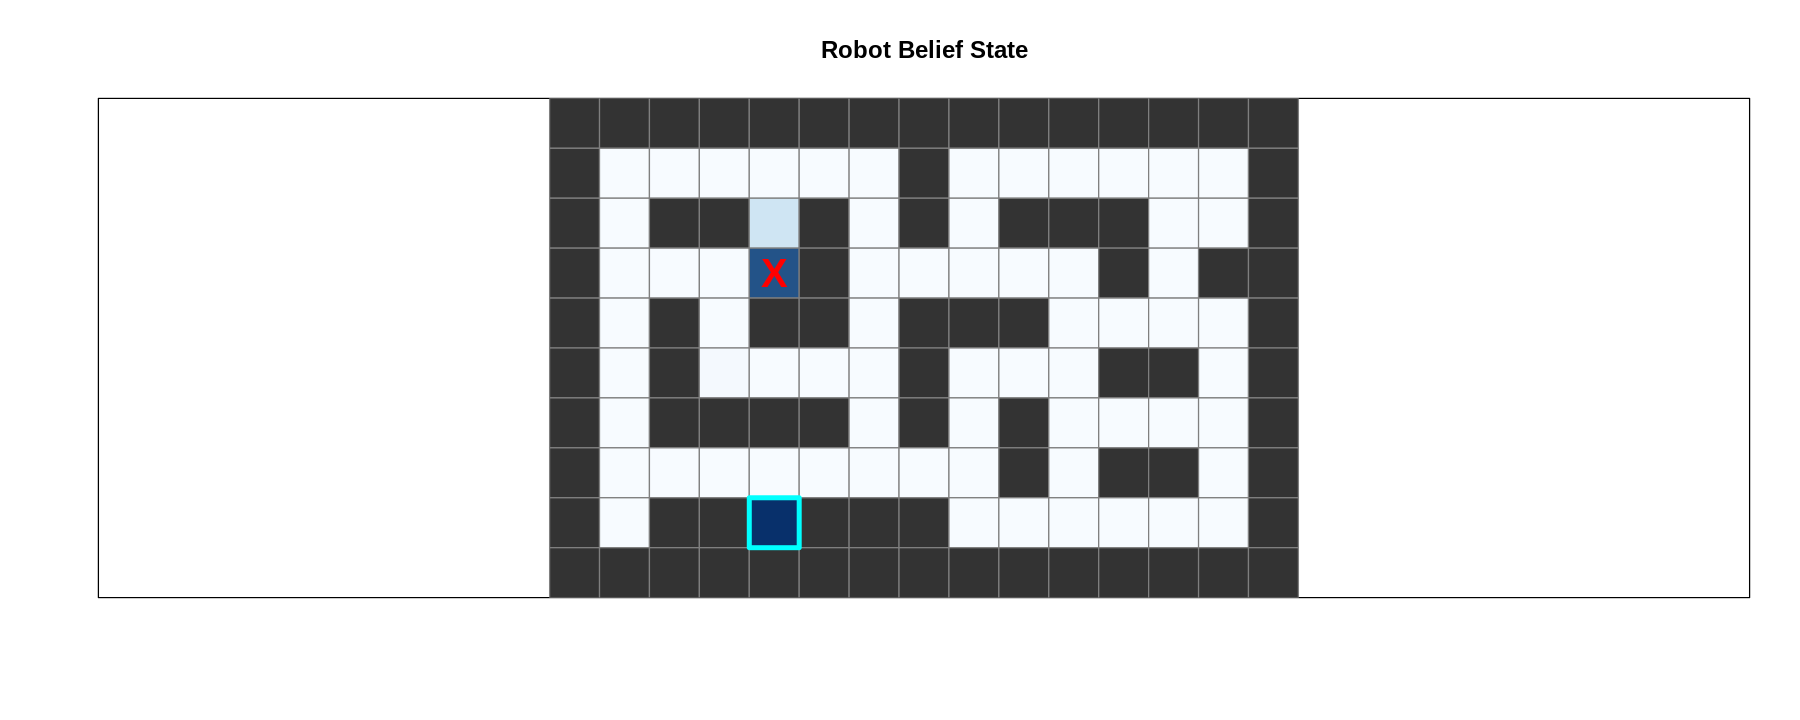

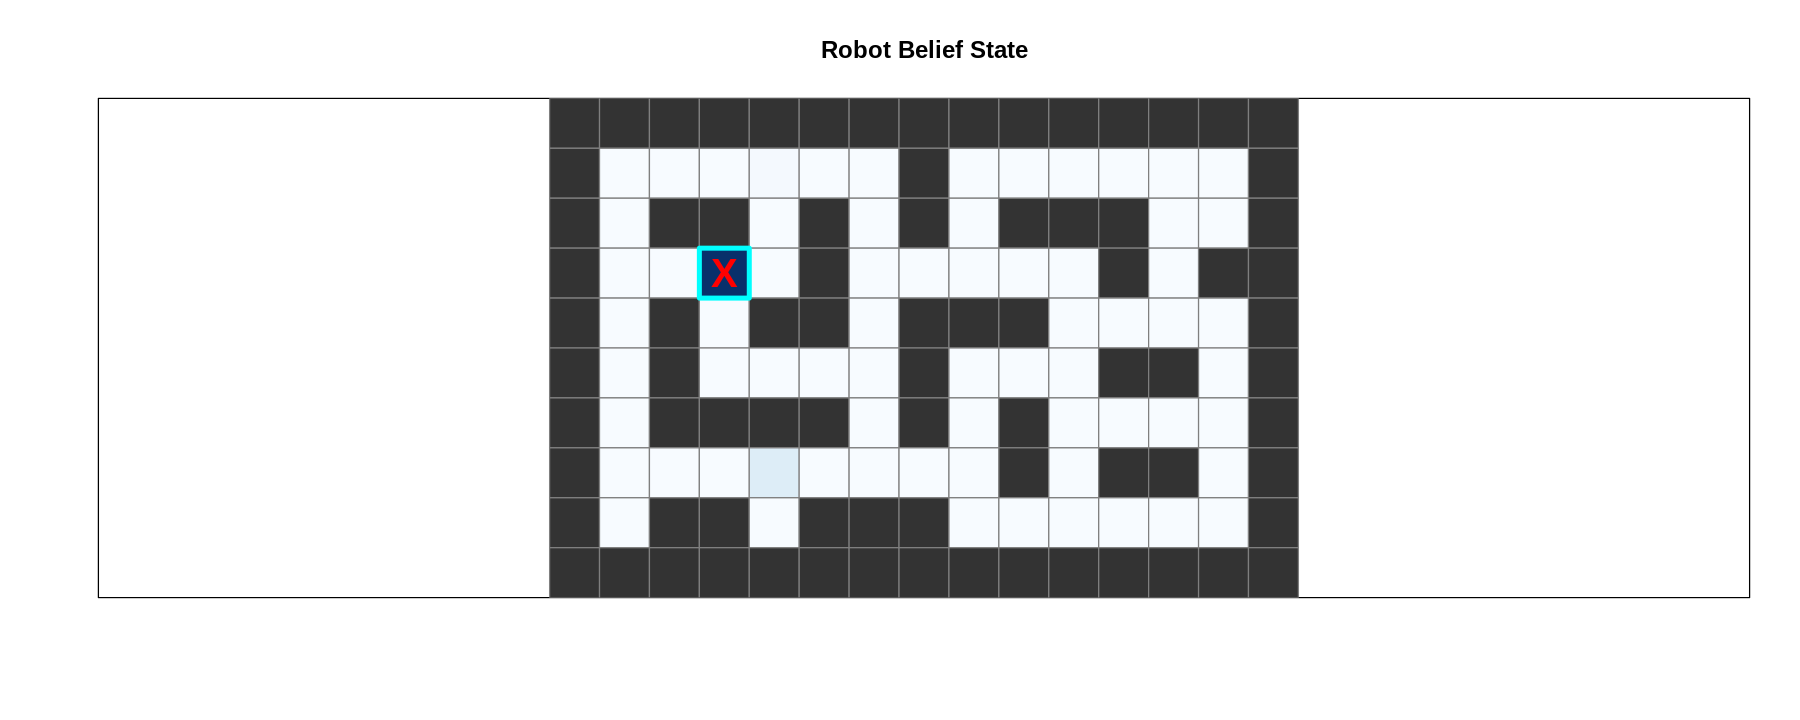

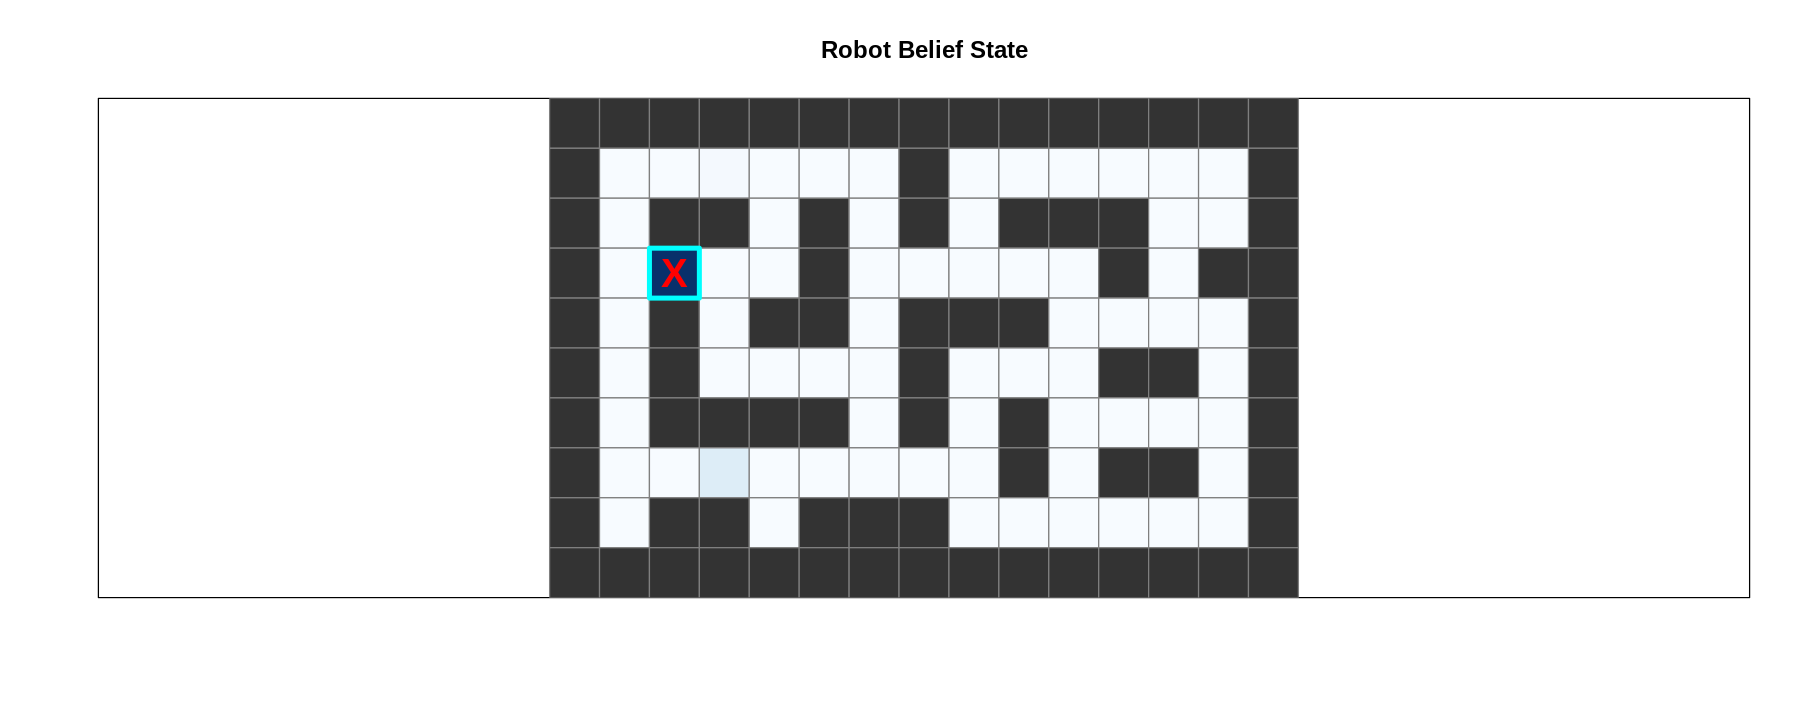

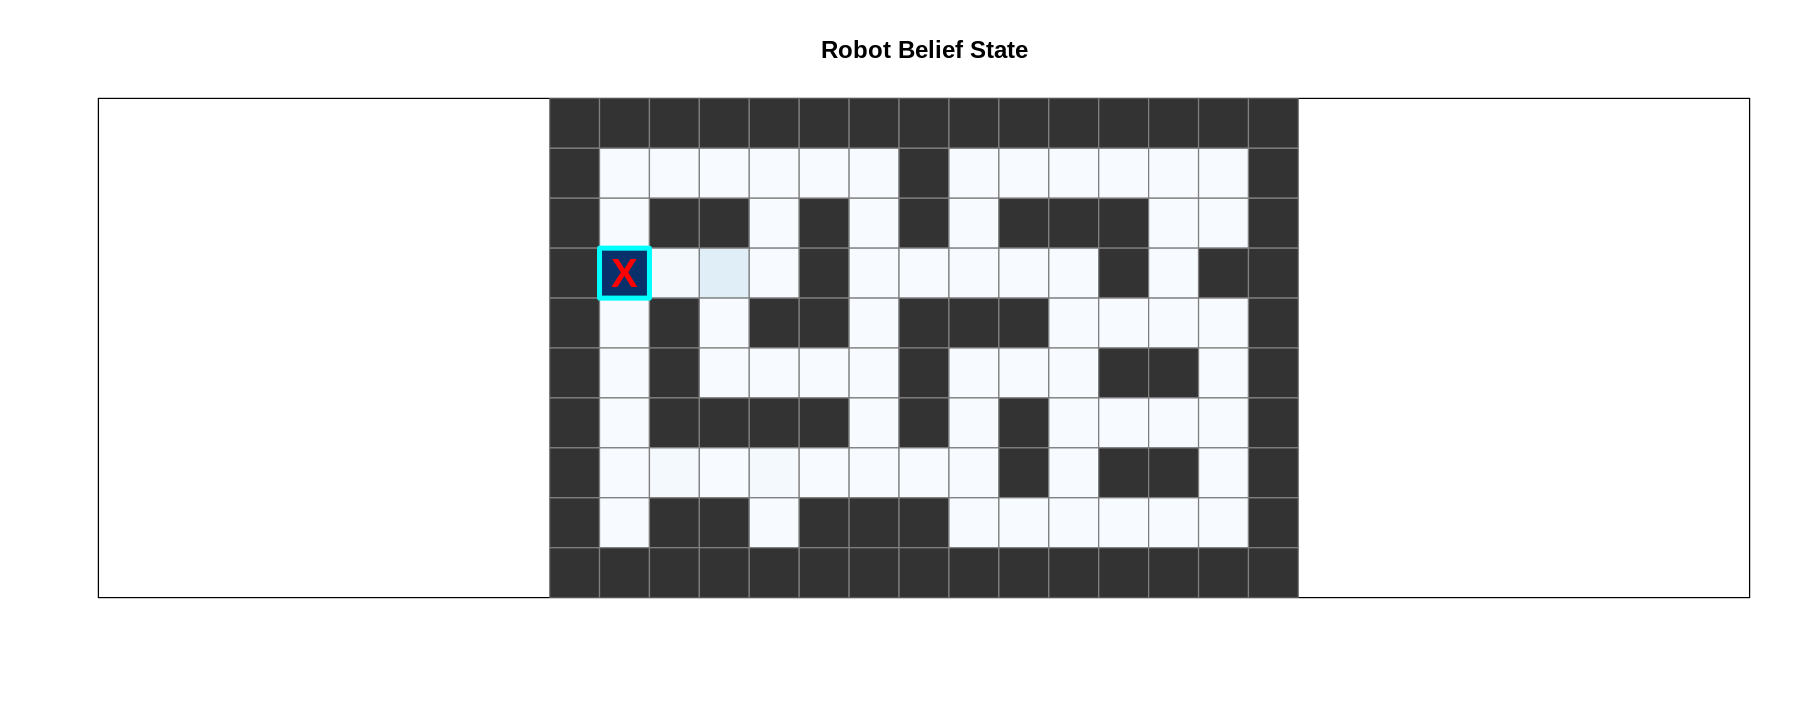

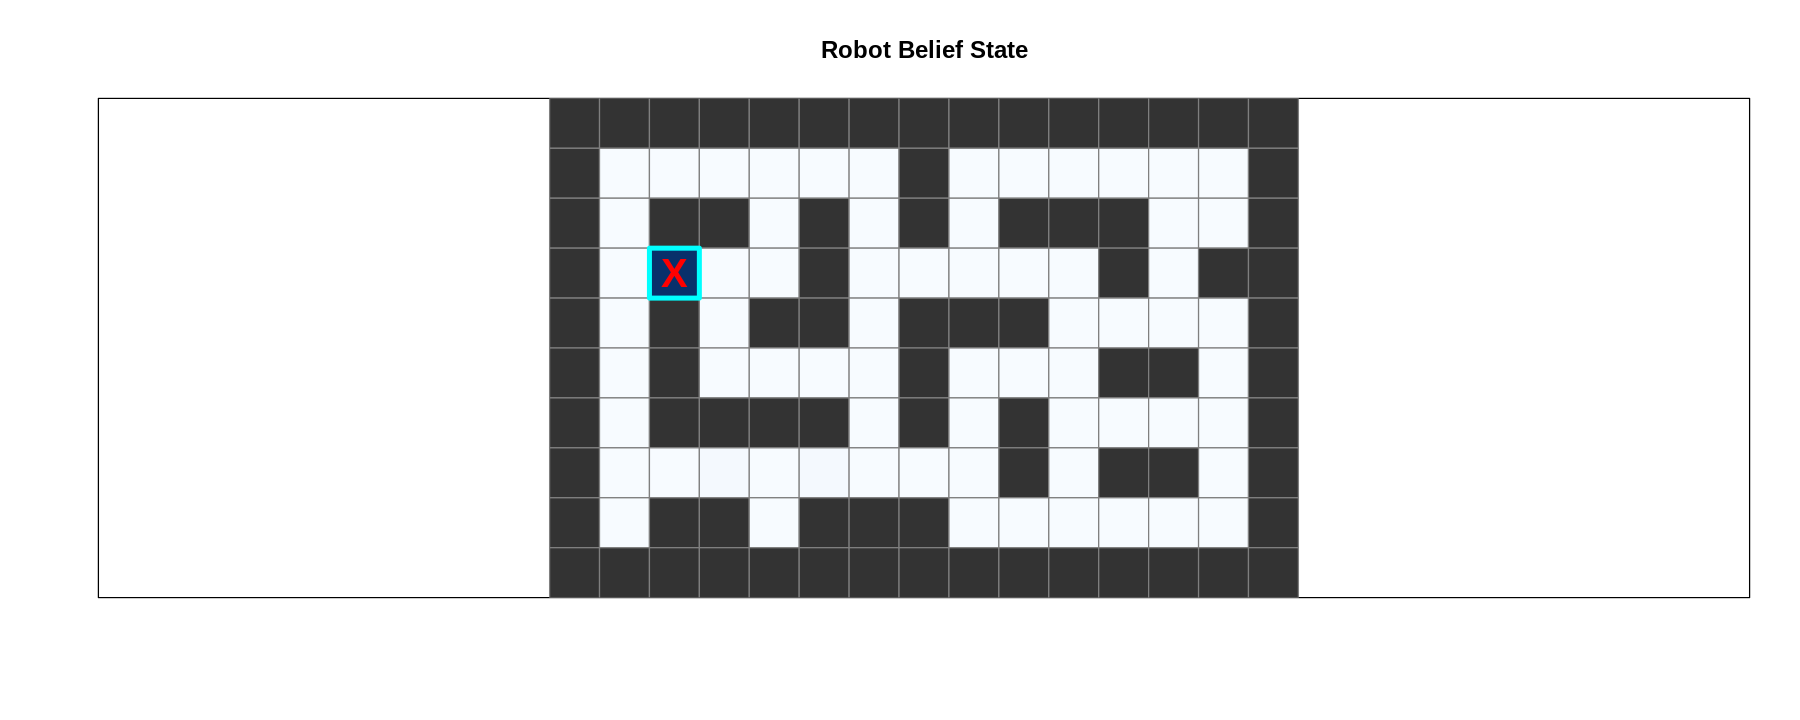

In [ ]:
for(i in 1:12) {
  plot_belief_map(map, beliefs[[i]], real_pos[[i]])
}

### 8. **TO-DO:** Evaluate the results 📈 (10 points🎯)
Pass the output of your model to the following functions. Function `plot_belief_maxima` plots our maximum likelihood belief versus state. Function `plot_belief_accuracy` prints the number of correct predictions in each group of 5 along with the overall accuracy.

In [ ]:
plot_belief_maxima <- function(beliefs) {
  if (!is.list(beliefs) || !all(sapply(beliefs, is.matrix))) {
    stop("Input must be a list of matrices.")
  }

    max_values <- sapply(beliefs, max)

  df <- data.frame(
    Index = seq_along(max_values),
    MaxValue = max_values
  )

  return(
    ggplot(df, aes(x = Index, y = MaxValue)) +
    geom_line(color = "blue", linewidth = 1) +
    geom_point(color = "red", size = 3) +
    labs(
      title = "Maximum Value of Each Belief Matrix",
      x = "Matrix Index",
      y = "Maximum Value"
    ) +
    theme_minimal()
  )
}


In [ ]:
plot_belief_accuracy <- function(beliefs, real_pos) {
  if (length(beliefs) != length(real_pos)) {
    stop("beliefs and real_pos must have the same length.")
  }

  predicted_pos <- lapply(beliefs, function(b) {
    idx <- which(b == max(b), arr.ind = TRUE)
    return(idx[1, ])
  })

  correct <- mapply(function(p, r) all(p == r), predicted_pos, real_pos)

  n <- length(correct)
  group_indices <- ceiling(seq_len(n) / 5)
  correct_counts <- tapply(correct, group_indices, sum)

  df <- data.frame(
    Group = factor(seq_along(correct_counts)),
    Correct = as.numeric(correct_counts)
  )

  overall_acc <- mean(correct)
  cat(sprintf("Overall accuracy: %.2f%%\n", 100 * overall_acc))

  return(
    ggplot(df, aes(x = Group, y = Correct)) +
    geom_col(fill = "steelblue") +
    labs(
      title = "Correct Predictions per 5 Belief Blocks",
      x = "Group of 5 Beliefs",
      y = "Number of Correct Predictions"
    ) +
    theme_minimal()
  )

}



8.1. Change the model error percentage according to the table below and compare the graphs for 300 moves.
+ At each step, change the `SENSOR_ERROR` and `MOVE_ERROR` values ​​and call the `model` function again and plot the model output with given functions.

| Sensor error | Movement Error |
| ------------ | -------------- |
| 0.01         | 0.01           |
| 0.05         | 0.05           |
| 0.6          | 0.6            |
| 0.6          | 0.001          |
| 0.001        | 0.6            |

+ **Note:** Don't use `for` and plot each graph in a **separate cell**.

8.2. Finally, analyze the results and check the reason for the behavior of each chart. Also, compare the importance of sensor error and movement error according to the results.

Overall accuracy: 99.00%


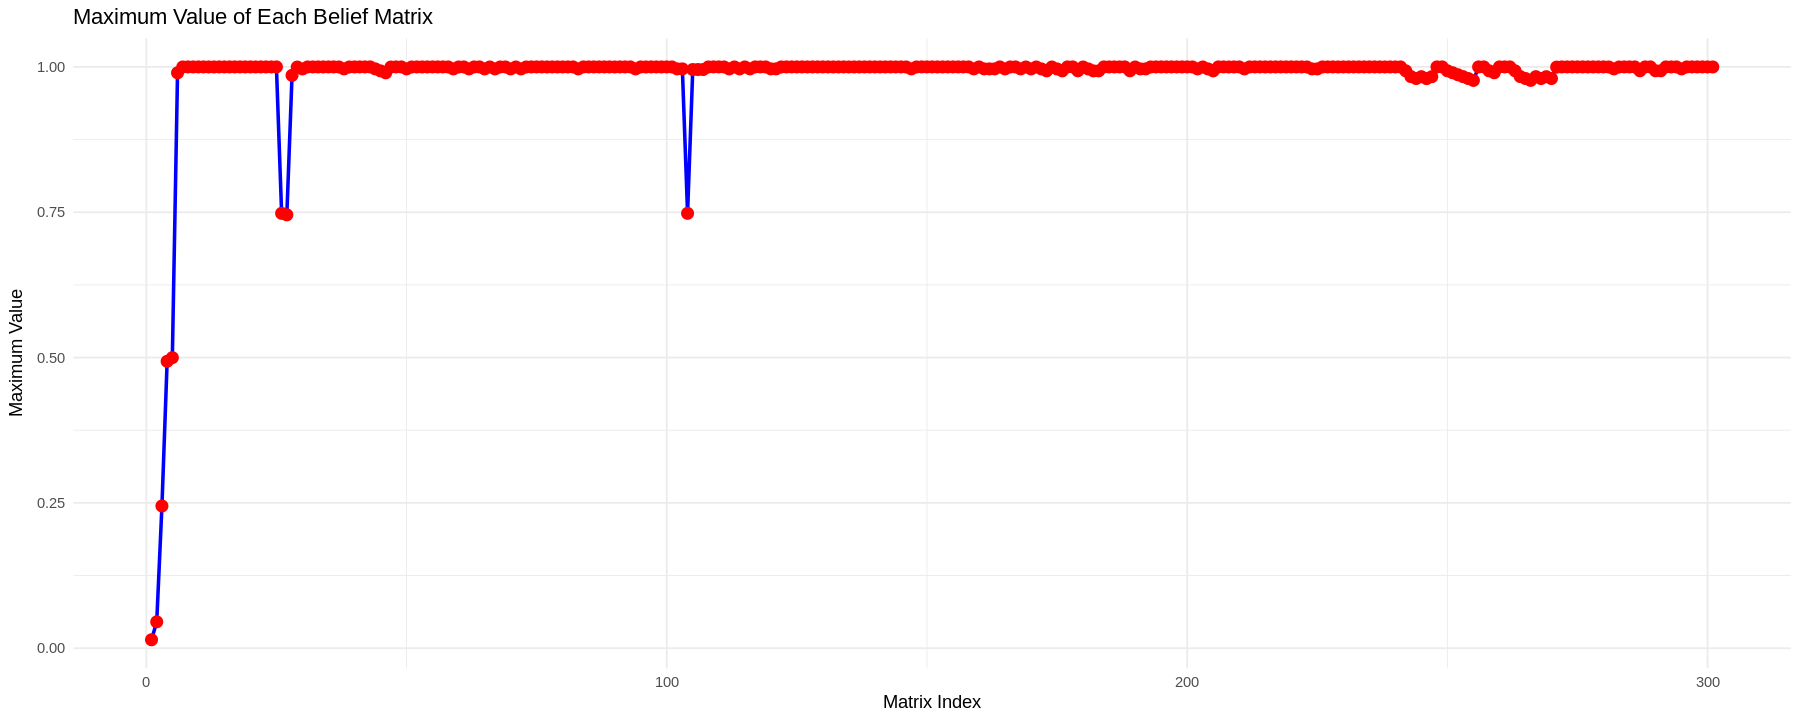

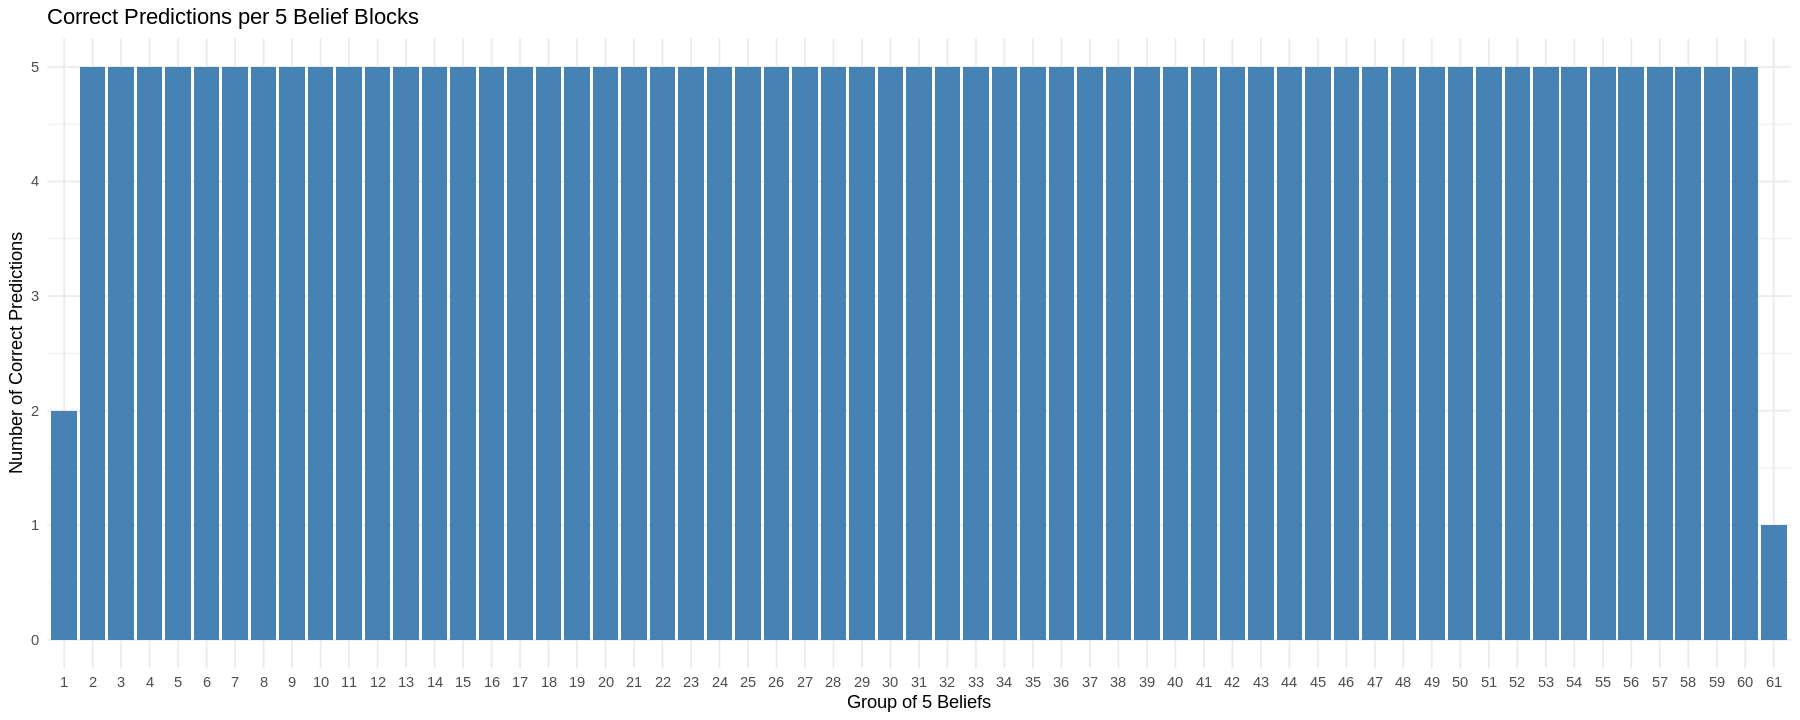

In [ ]:
# TO DO: {0.01, 0.01}

# Set error parameters
SENSOR_ERROR <- 0.01
MOVE_ERROR <- 0.01

# Run the model with new error parameters
result_low_error <- model(map, chosen_dirs)
beliefs_low_error <- result_low_error$beliefs
real_pos_low_error <- result_low_error$real_pos

print(plot_belief_maxima(beliefs_low_error))

print(plot_belief_accuracy(beliefs_low_error, real_pos_low_error))

Overall accuracy: 98.67%


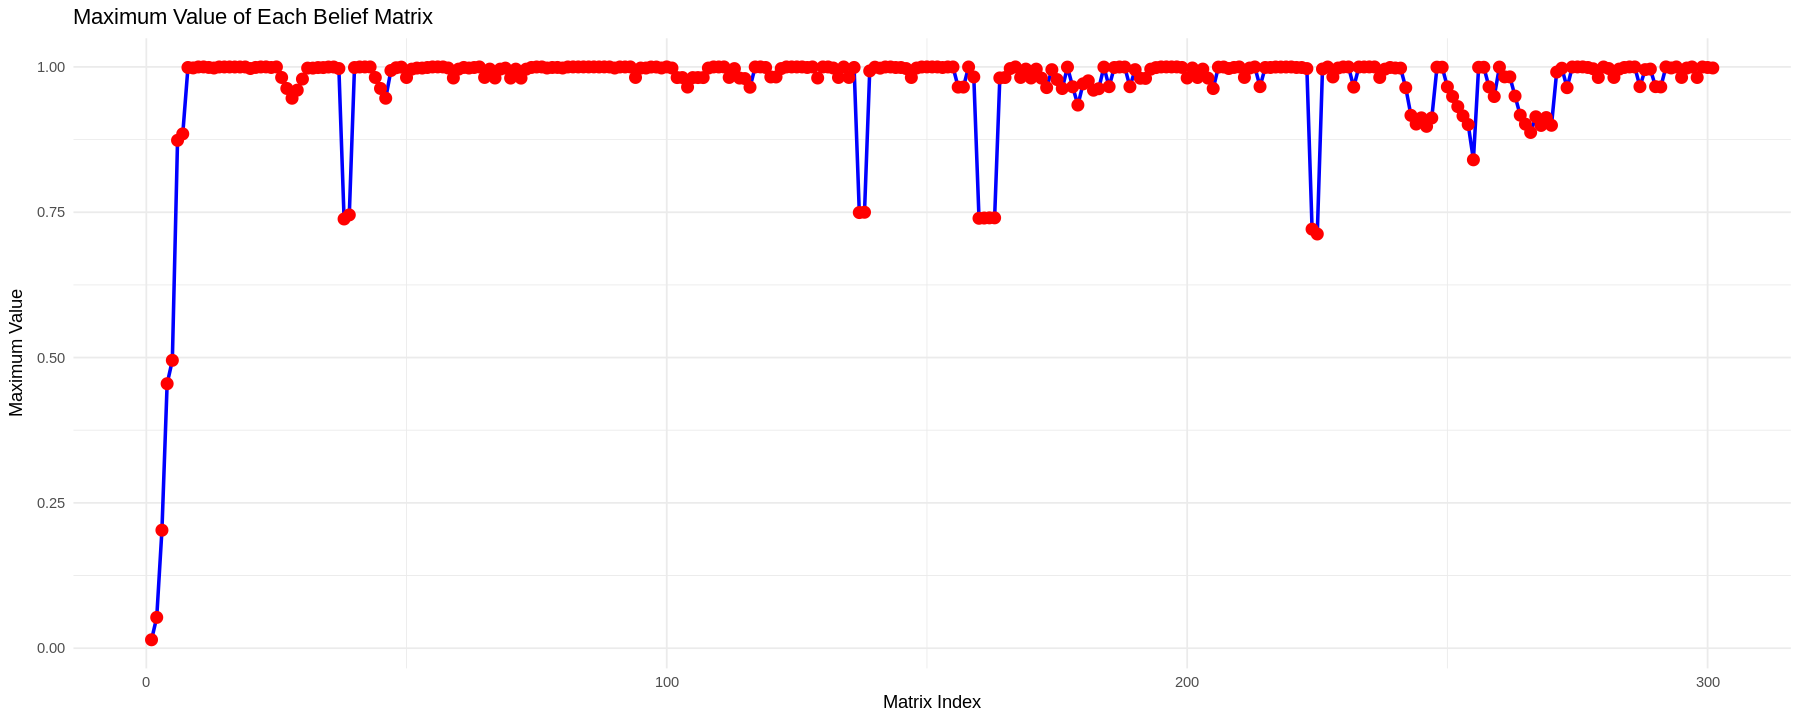

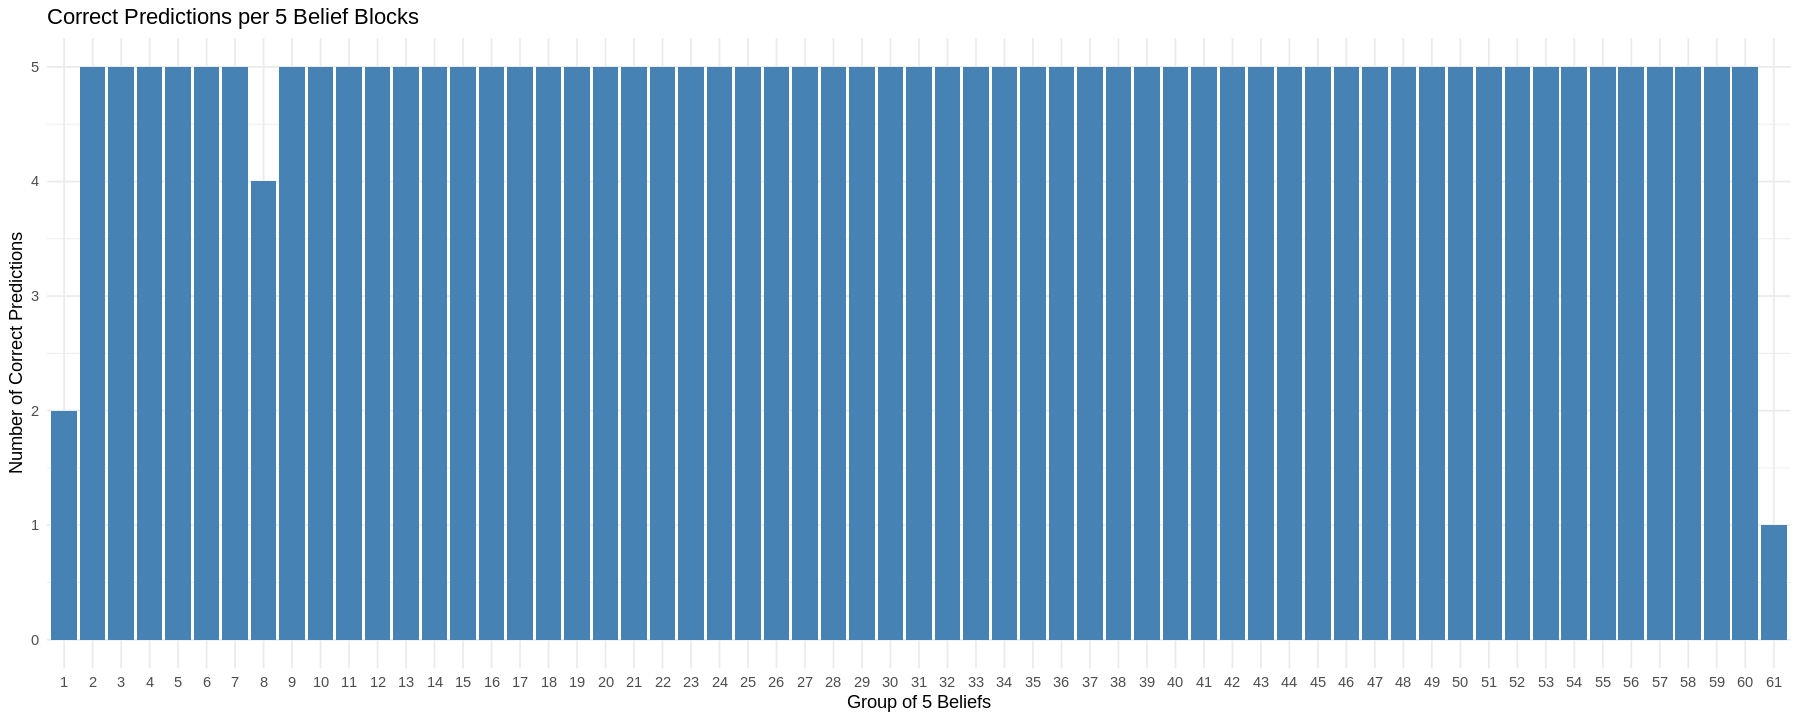

In [ ]:
# TO DO: {0.05, 0.05}

# Set error parameters
SENSOR_ERROR <- 0.05
MOVE_ERROR <- 0.05

# Run the model with new error parameters
result_low_error <- model(map, chosen_dirs)
beliefs_low_error <- result_low_error$beliefs
real_pos_low_error <- result_low_error$real_pos

print(plot_belief_maxima(beliefs_low_error))

print(plot_belief_accuracy(beliefs_low_error, real_pos_low_error))

Overall accuracy: 8.64%


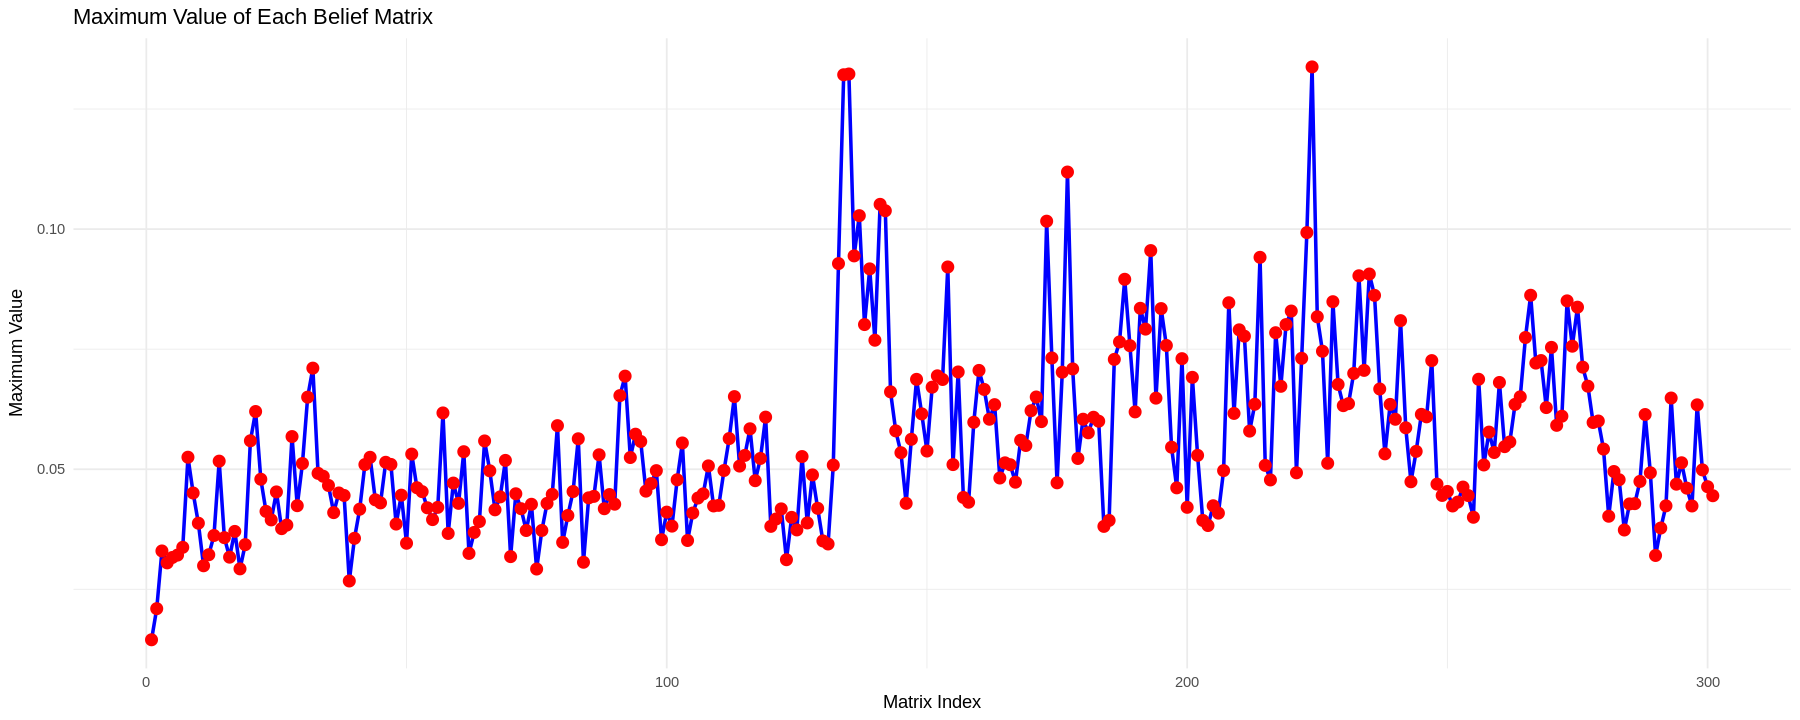

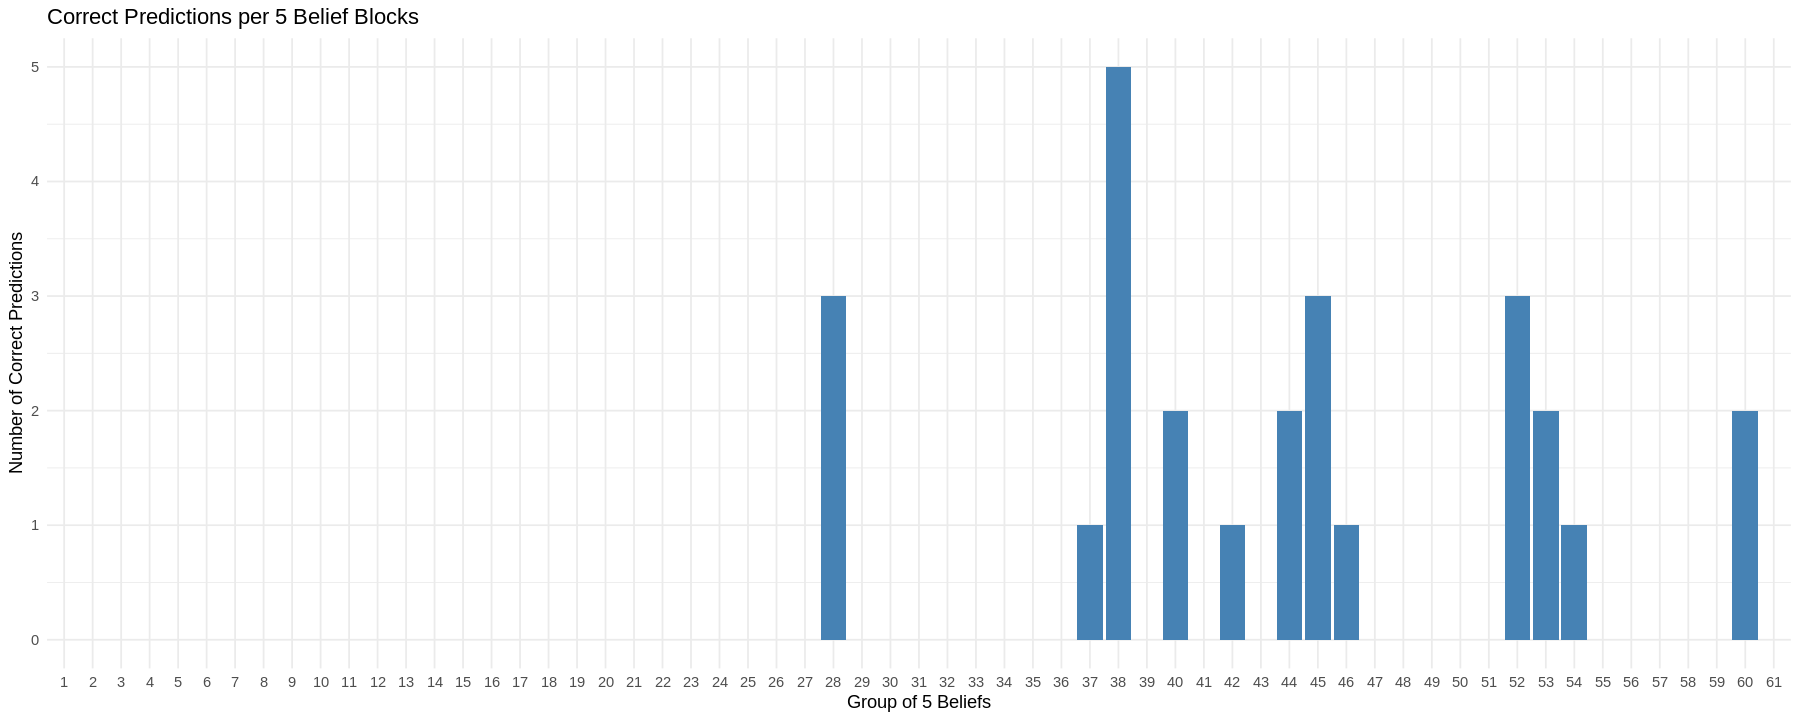

In [ ]:
# TO DO: {0.6, 0.6}

# Set error parameters
SENSOR_ERROR <- 0.6
MOVE_ERROR <- 0.6

# Run the model with new error parameters
result_low_error <- model(map, chosen_dirs)
beliefs_low_error <- result_low_error$beliefs
real_pos_low_error <- result_low_error$real_pos

print(plot_belief_maxima(beliefs_low_error))

print(plot_belief_accuracy(beliefs_low_error, real_pos_low_error))

Overall accuracy: 74.75%


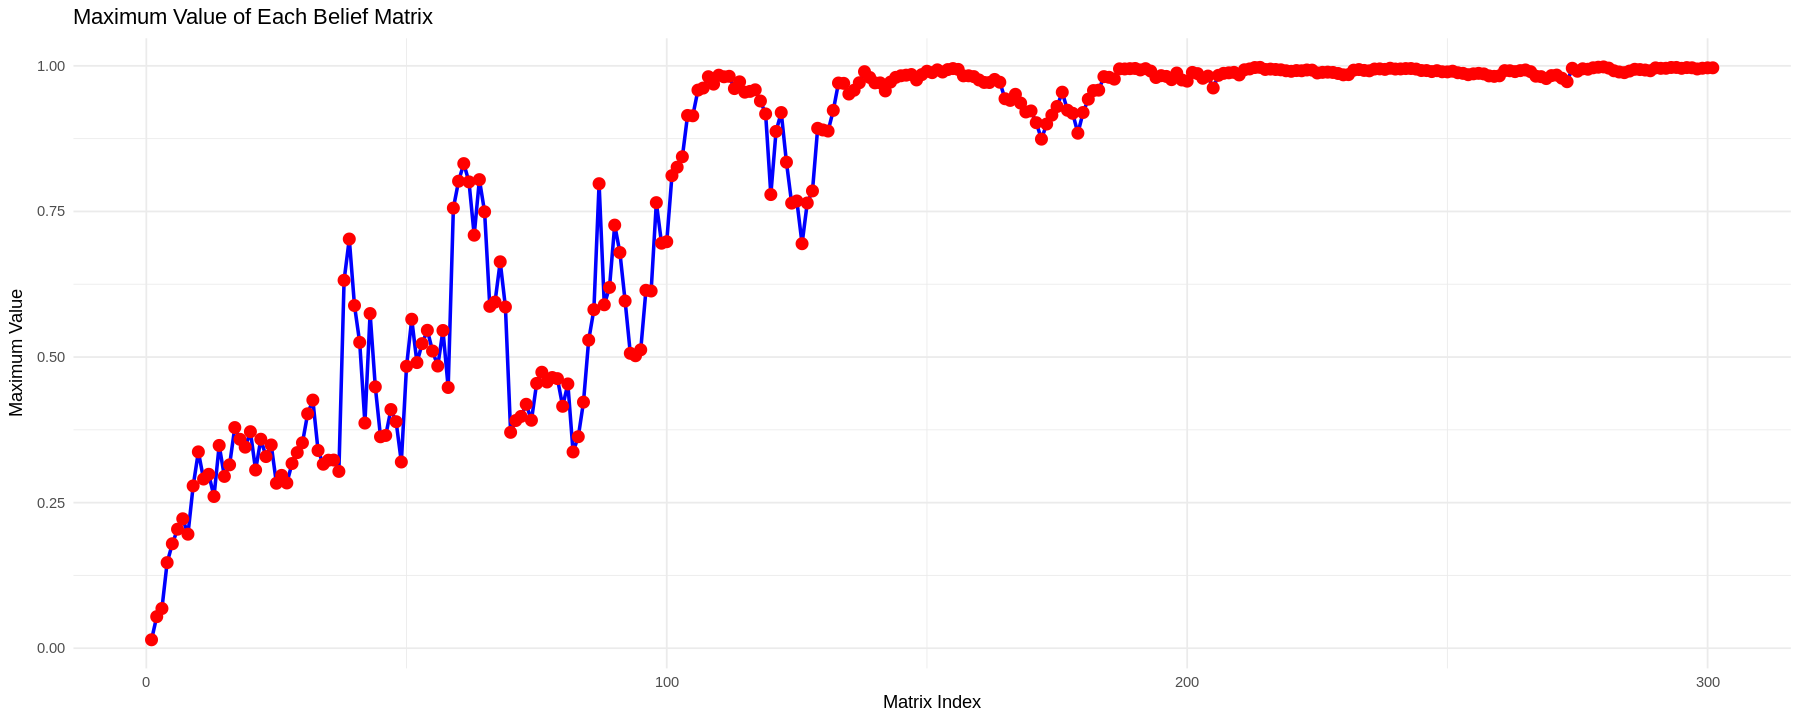

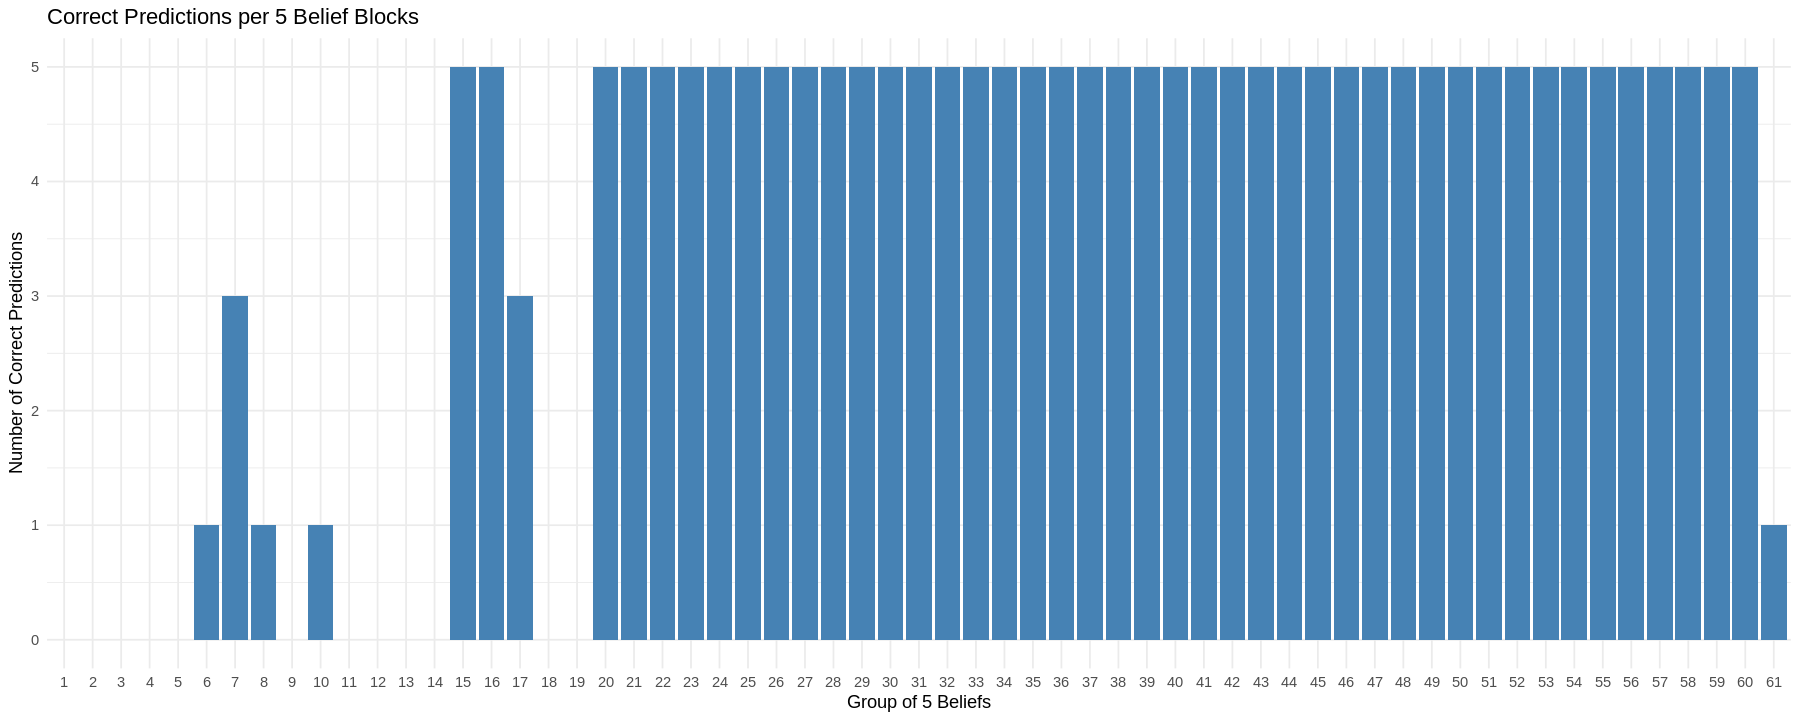

In [ ]:
# TO DO: {0.6, 0.001}

# Set error parameters
SENSOR_ERROR <- 0.6
MOVE_ERROR <- 0.001

# Run the model with new error parameters
result_low_error <- model(map, chosen_dirs)
beliefs_low_error <- result_low_error$beliefs
real_pos_low_error <- result_low_error$real_pos

print(plot_belief_maxima(beliefs_low_error))

print(plot_belief_accuracy(beliefs_low_error, real_pos_low_error))

Overall accuracy: 94.02%


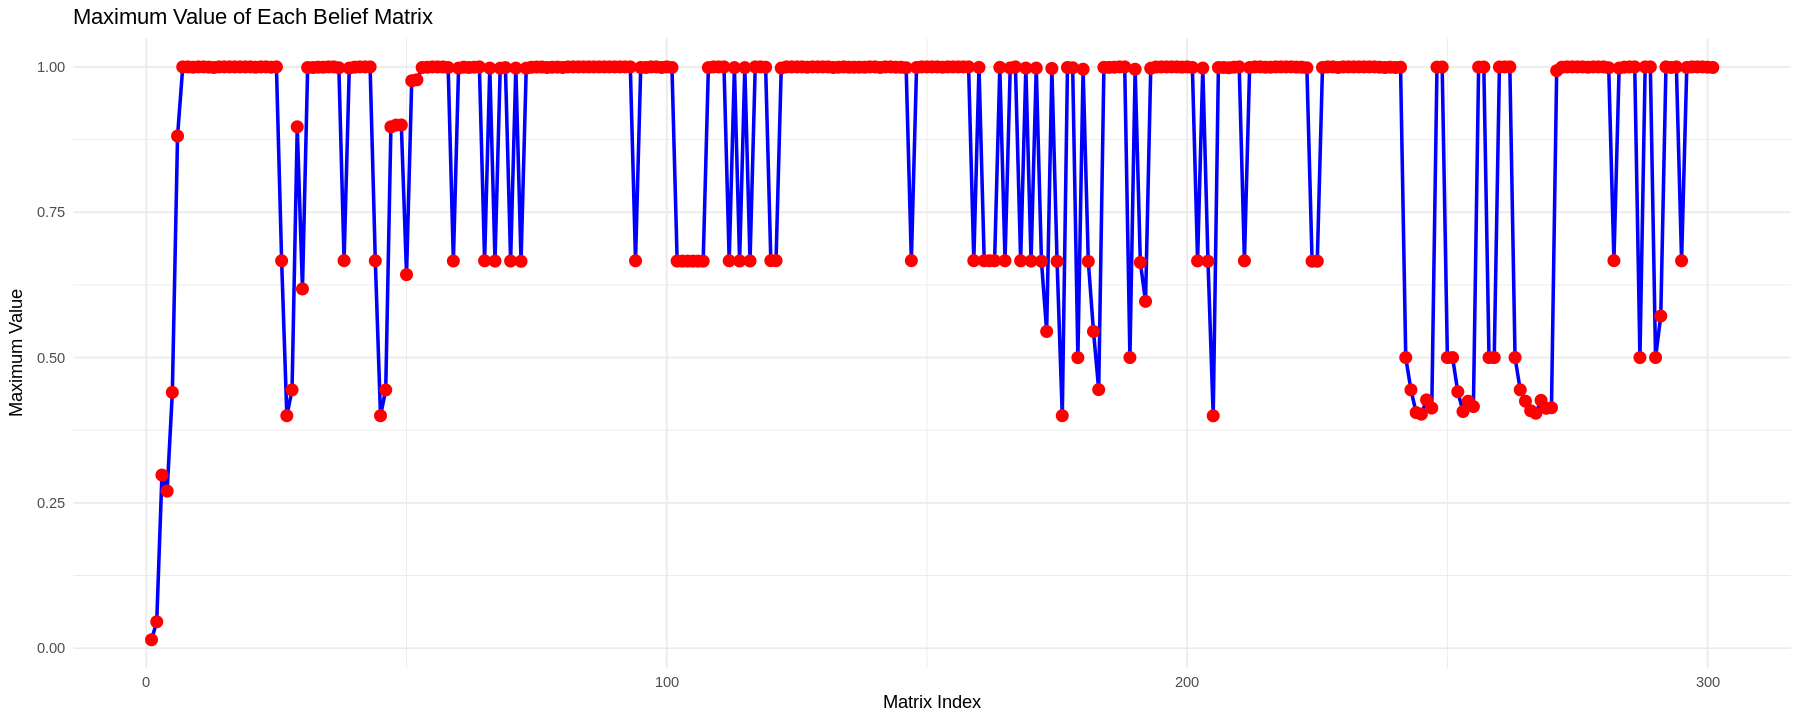

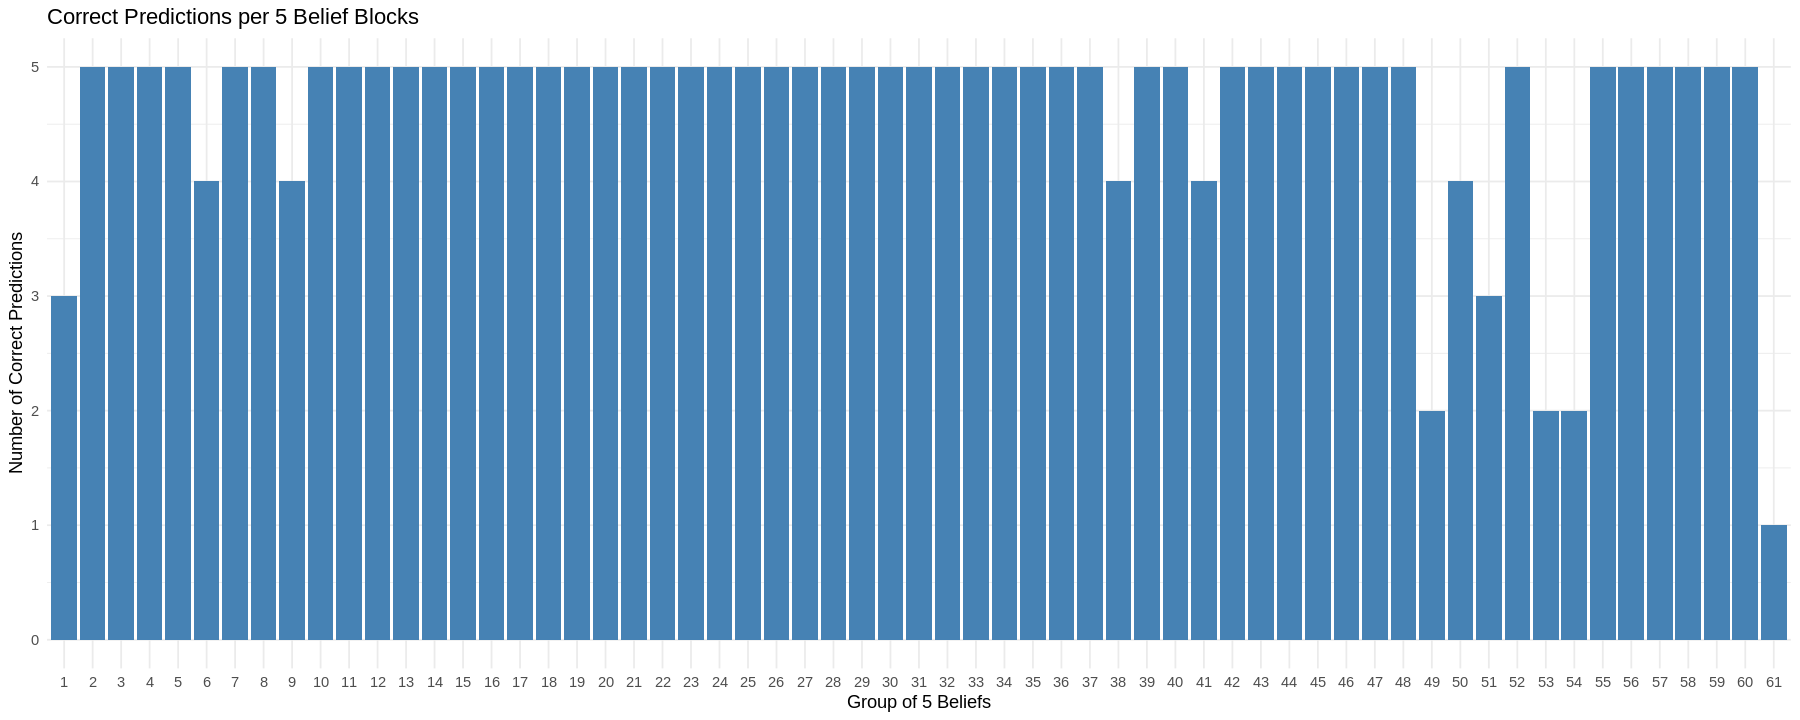

In [ ]:
# TO DO: {0.001, 0.6}

# Set error parameters
SENSOR_ERROR <- 0.001
MOVE_ERROR <- 0.6

# Run the model with new error parameters
result_low_error <- model(map, chosen_dirs)
beliefs_low_error <- result_low_error$beliefs
real_pos_low_error <- result_low_error$real_pos

print(plot_belief_maxima(beliefs_low_error))

print(plot_belief_accuracy(beliefs_low_error, real_pos_low_error))

🔴 **8.2 TO DO**

## Summary of Error Scenarios and Comparison of Sensor vs. Movement Error Importance

The analysis of various error scenarios (low, medium, high, high sensor/low movement, low sensor/high movement) in the robot localization model reveals that:

*   **Low Errors (0.01/0.01 and 0.05/0.05):** The model performs exceptionally well, achieving high accuracy (98-99%) and confidence due to reliable sensor data and movement predictions.

*   **High Errors (0.6/0.6):** The model completely breaks down, with very low accuracy (8-10%) and high uncertainty, as both sensor and movement information are unreliable.

*   **High Sensor Error (0.6), Low Movement Error (0.001):** Accuracy is moderate (70-75%). Although movement is reliable, the highly inaccurate sensor data limits the model's ability to consistently pinpoint the robot's location. The model struggles to build strong confidence.

*   **Low Sensor Error (0.001), High Movement Error (0.6):** Accuracy is significantly higher (90-95%) compared to the high sensor error scenario. Precise sensor readings allow the model to effectively correct for uncertainties introduced by unpredictable movement, leading to higher confidence in localization.

**Conclusion:** Sensor accuracy is more critical than movement accuracy for robust robot localization in this model. High-quality sensor data provides strong, unambiguous evidence that can effectively mitigate the uncertainty from unreliable movement, allowing the model to accurately localize the robot.